In [ ]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 0: 프로젝트 맵 / 방향성 정의
# =============================================================================
#
# [노트북 목적]
# H팩터 (섹터 로테이션) 단독 검증
# → D팩터와의 상관관계 보정 방법론 수립
# → A-D 상관관계 해결의 참고 자료로 활용
#
# =============================================================================
# [가설 정의 — 진짜 가설 풀 타입 H]
# =============================================================================
#
# H-1: 섹터 모멘텀
#   11개 GICS 섹터 중 최근 12개월 수익률 상위 3개 섹터 소속 종목에 가산
#   월간 리밸런싱
#
# H-2: 섹터 역추세
#   최근 1개월 가장 많이 빠진 섹터 소속 종목 매수, 1개월 보유 후 청산
#
# H-3: 리스크 온/오프 로테이션
#   VIX > 25 → 방어 섹터 (Utilities, Health Care, Consumer Staples)
#   VIX < 20 → 공격 섹터 (Technology, Consumer Discretionary, Financials)
#
# =============================================================================
# [H팩터의 위치 — 멀티팩터 구조에서]
# =============================================================================
#
# H는 A(밸류), D(모멘텀)와 동등한 독립 팩터
# 종목 고유 특성이 아닌, "종목이 속한 섹터의 환경 유불리"를 측정
#
# 최종 멀티팩터 합산: A_z + D_z + H_z + ... (동등 가중 또는 레짐 기반 가중)
#
# =============================================================================
# [D-H 상관관계 문제 — 핵심 이슈]
# =============================================================================
#
# 우려: H-1(섹터 모멘텀)과 D(종목 모멘텀) 모두 "과거 수익률 기반"
#   → 동일 정보를 이중 반영할 위험
#
# 인과 방향: 섹터 환경(H) → 개별 종목 모멘텀(D)
#   "거시적 섹터 바람이 개별 종목 추세에 영향을 준다"
#   따라서 D에서 H 성분을 제거해야 함 (D를 H에 회귀, 잔차 = 순수 종목 모멘텀)
#
# 보정 방법 검토 순서:
#   방법 2: 상관 비례 감산 — D 스코어에서 H와 겹치는 만큼 할인
#   방법 1: 잔차(residual) 방식 — D_adj = D - β×H (직교화)
#   방법 3: 포트폴리오 레벨 처리 — 팩터 간 공분산 기반 비중 조절 (Risk Parity)
#           ※ 다른 팩터 충분히 쌓인 후 돌아와서 수행
#
# =============================================================================
# [셀 구조]
# =============================================================================
#
# 셀 0: 이 주석 (프로젝트 맵)
# 셀 1: 환경/경로/유틸
# 셀 2: 데이터 로드 (주가 + 레짐 + 유니버스/GICS 섹터 매핑)
# 셀 3: 섹터별 월간 수익률 패널 생성 (11개 섹터 × 월)
# 셀 4: 레짐별 섹터 성과 분석 — 어떤 섹터가 어떤 레짐에서 유리한가
# 셀 5: H 스코어 설계 — 레짐 × 섹터 → 점수 매핑
# 셀 6: 종목 레벨 H팩터 부여 + 단독 백테스트
# 셀 7: 레짐별 백테스트
# 셀 8: D-H 상관관계 측정 (cross-sectional, 레짐별)
# 셀 9: 보정 방법 2 — 상관 비례 감산 적용 + 성과 비교
# 셀 10: 보정 방법 1 — 잔차 직교화 적용 + 성과 비교
# 셀 11: 결론 + A-D 보정 시사점
#
# =============================================================================
# [관련 파일]
# =============================================================================
#
# 데이터:
#   data/interim/yahoo_adjclose_wide.parquet   — 주가 (wide)
#   data/interim/yahoo_prices_long.parquet     — 주가 (long)
#   data/interim/regime_indicators_combined.parquet — 레짐 (regime_v2)
#   data/meta/sp500_universe.parquet           — 유니버스 + GICS 섹터
#
# 참고 노트북:
#   02_A.ipynb    — A팩터 (Value×Catalyst), 유효 레짐: Neutral, Recovery_Late
#   02_D.ipynb    — D팩터 (Momentum), 유효 레짐: Neutral, Contraction
#   01_DataLoader_Macro.ipynb — 레짐 분류 (regime_v2)
#
# =============================================================================
# [파라미터 (초기값, 셀 진행하며 조정)]
# =============================================================================
#
# LOOKBACK_M     = 12      # 섹터 모멘텀 룩백 (개월)
# TOP_SECTORS    = 3       # 상위 N개 섹터 선정
# TOP_N          = 30      # 최종 종목 수 (기존 팩터와 동일)
# REGIME_COL     = "regime_v2"
#
# =============================================================================

In [1]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 1: 환경 / 경로 / 유틸
# =============================================================================
# 목적: SSOT 경로 로드, 공통 유틸 함수 정의
# 산출물: 없음 (설정만)
# 주의: 다른 02_ 노트북과 동일 구조 유지
# =============================================================================

import warnings, os, json, logging
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── .env 로드 & SSOT 경로 ──────────────────────────────────────────────
load_dotenv(Path(r"C:\QP2\.env"))
QP2_ROOT    = Path(os.getenv("QP2_ROOT", r"C:\QP2"))
DATA_DIR    = QP2_ROOT / "data"
RAW_DIR     = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
META_DIR    = DATA_DIR / "meta"

# ── 로깅 ────────────────────────────────────────────────────────────────
logger = logging.getLogger("H_01")
logger.setLevel(logging.INFO)
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s",
                                     datefmt="%H:%M:%S"))
    logger.addHandler(h)

# ── 파라미터 ─────────────────────────────────────────────────────────────
LOOKBACK_M   = 12          # 섹터 모멘텀 룩백 (개월)
TOP_SECTORS  = 3           # 상위 N개 섹터 선정
TOP_N        = 30          # 최종 종목 수
REGIME_COL   = "regime_v2" # 레짐 컬럼명

# ── 유틸 함수 ────────────────────────────────────────────────────────────
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 윈저화 (극단값 클리핑)"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col):
    """날짜별 cross-sectional z-score"""
    return df.groupby("date")[col].transform(lambda x: (x - x.mean()) / x.std())

def calc_perf(ret_series, label=""):
    """수익률 시리즈 → CAGR, Sharpe, MaxDD 딕셔너리 반환"""
    cum   = (1 + ret_series).cumprod()
    n_yr  = len(ret_series) / 12
    cagr  = cum.iloc[-1] ** (1 / n_yr) - 1 if n_yr > 0 else 0
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(12) if ret_series.std() > 0 else 0
    dd     = cum / cum.cummax() - 1
    maxdd  = dd.min()
    return {"label": label, "CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd,
            "n_months": len(ret_series)}

def calc_tstat(port_ret, bm_ret):
    """초과수익률 t-stat 계산"""
    excess = port_ret - bm_ret
    n = len(excess)
    if n < 3 or excess.std() == 0:
        return 0.0
    return (excess.mean() / excess.std()) * np.sqrt(n)

# ── 경로 확인 ────────────────────────────────────────────────────────────
logger.info(f"QP2_ROOT    : {QP2_ROOT}")
logger.info(f"INTERIM_DIR : {INTERIM_DIR}")
logger.info(f"META_DIR    : {META_DIR}")
logger.info(f"파라미터    : LOOKBACK={LOOKBACK_M}M, TOP_SECTORS={TOP_SECTORS}, TOP_N={TOP_N}")
print("셀 1 완료 ✅")

14:00:23 INFO QP2_ROOT    : C:\QP2
14:00:23 INFO INTERIM_DIR : C:\QP2\data\interim
14:00:23 INFO META_DIR    : C:\QP2\data\meta
14:00:23 INFO 파라미터    : LOOKBACK=12M, TOP_SECTORS=3, TOP_N=30


셀 1 완료 ✅


In [2]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 2: 데이터 로드
# =============================================================================
# 목적: 주가, 레짐, 유니버스(GICS 섹터) 로드 및 기본 전처리
# 산출물: px_wide, px_m, ret_1m, regime_m, master, sector_map
# 주의: GICS Sector 컬럼 존재 여부 확인 필요
# =============================================================================

# ── 1) 유니버스 (GICS 섹터 매핑 포함) ───────────────────────────────────
master = pd.read_parquet(META_DIR / "sp500_universe.parquet")
logger.info(f"master: {master.shape}, 컬럼: {list(master.columns)}")

# GICS Sector 컬럼명 확인 — 없으면 여기서 에러 잡아야 함
# 가능한 컬럼명: 'GICS Sector', 'gics_sector', 'sector' 등
sector_candidates = [c for c in master.columns if "sector" in c.lower() or "gics" in c.lower()]
logger.info(f"섹터 후보 컬럼: {sector_candidates}")

if len(sector_candidates) == 0:
    logger.warning("⚠️ GICS Sector 컬럼 없음! 수동 매핑 필요")
    SECTOR_COL = None
else:
    SECTOR_COL = sector_candidates[0]
    logger.info(f"섹터 컬럼 확정: '{SECTOR_COL}'")
    print(f"\n섹터 분포:\n{master[SECTOR_COL].value_counts()}")

# ticker → sector 매핑 딕셔너리
if SECTOR_COL:
    sector_map = master.set_index("ticker_yahoo")[SECTOR_COL].to_dict()
    n_sectors = master[SECTOR_COL].nunique()
    logger.info(f"섹터 수: {n_sectors}, 매핑된 종목: {len(sector_map)}")
else:
    sector_map = {}

# ── 2) 주가 데이터 ──────────────────────────────────────────────────────
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
if "date" in px_wide.columns:
    px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index)
logger.info(f"px_wide: {px_wide.shape} ({px_wide.index.min().date()} ~ {px_wide.index.max().date()})")

# 월말 리샘플링
px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

# sector_map에 있는 종목만 필터
common_tickers = sorted(set(ret_1m.columns) & set(sector_map.keys()))
ret_1m = ret_1m[common_tickers]
px_m   = px_m[common_tickers]
logger.info(f"공통 종목 수: {len(common_tickers)}")

# ── 3) 레짐 데이터 ──────────────────────────────────────────────────────
regime_raw = pd.read_parquet(INTERIM_DIR / "regime_indicators_combined.parquet")
if "date" in regime_raw.columns:
    regime_raw = regime_raw.set_index("date")
regime_raw.index = pd.to_datetime(regime_raw.index)

# 월말로 리샘플링 (가장 마지막 레짐 사용)
regime_m = regime_raw[[REGIME_COL]].resample("ME").last()
logger.info(f"regime_m: {regime_m.shape}, 레짐 분포:\n{regime_m[REGIME_COL].value_counts()}")

# ── 4) 공통 기간 정렬 ───────────────────────────────────────────────────
common_dates = sorted(set(ret_1m.index) & set(regime_m.index))
ret_1m   = ret_1m.loc[common_dates]
px_m     = px_m.loc[common_dates]
regime_m = regime_m.loc[common_dates]

# NaN 많은 초기 구간 제거 (종목의 50% 이상 데이터 있는 날짜만)
valid_mask = ret_1m.notna().sum(axis=1) > len(common_tickers) * 0.5
ret_1m   = ret_1m.loc[valid_mask]
px_m     = px_m.loc[valid_mask]
regime_m = regime_m.loc[valid_mask]

# EW 벤치마크
ew_ret = ret_1m.mean(axis=1)

logger.info(f"최종 기간: {ret_1m.index.min().date()} ~ {ret_1m.index.max().date()}")
logger.info(f"최종 월 수: {len(ret_1m)}, 종목 수: {ret_1m.shape[1]}")

print(f"\n셀 2 완료 ✅")
print(f"  기간: {ret_1m.index.min().date()} ~ {ret_1m.index.max().date()}")
print(f"  월 수: {len(ret_1m)}, 종목: {ret_1m.shape[1]}")
if SECTOR_COL:
    print(f"  섹터: {n_sectors}개")

14:02:23 INFO master: (503, 6), 컬럼: ['ticker_sp', 'ticker_yahoo', 'cik', 'security_name', 'GICS Sector', 'GICS Sub-Industry']
14:02:23 INFO 섹터 후보 컬럼: ['GICS Sector', 'GICS Sub-Industry']
14:02:23 INFO 섹터 컬럼 확정: 'GICS Sector'
14:02:23 INFO 섹터 수: 11, 매핑된 종목: 503
14:02:24 INFO px_wide: (16131, 503) (1962-01-02 ~ 2026-02-04)
14:02:24 INFO 공통 종목 수: 503



섹터 분포:
GICS Sector
Industrials               80
Financials                76
Information Technology    70
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64


14:02:24 INFO regime_m: (770, 1), 레짐 분포:
regime_v2
5_Expansion         249
4_Recovery_Late     154
0_Neutral           148
3_Contraction        81
2_Recovery_Early     54
6_Peak               42
1_Crash              42
Name: count, dtype: int64
14:02:24 INFO 최종 기간: 1992-01-31 ~ 2026-02-28
14:02:24 INFO 최종 월 수: 410, 종목 수: 503



셀 2 완료 ✅
  기간: 1992-01-31 ~ 2026-02-28
  월 수: 410, 종목: 503
  섹터: 11개


14:03:56 INFO ret_long: (167045, 4) (NaN 제거 후)
14:03:56 INFO 섹터 분포:
sector
Communication Services    23
Consumer Discretionary    48
Consumer Staples          36
Energy                    22
Financials                76
Health Care               60
Industrials               80
Information Technology    70
Materials                 26
Real Estate               31
Utilities                 31
Name: ticker, dtype: int64
14:03:56 INFO sect_ret: (410, 11) (['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities'])


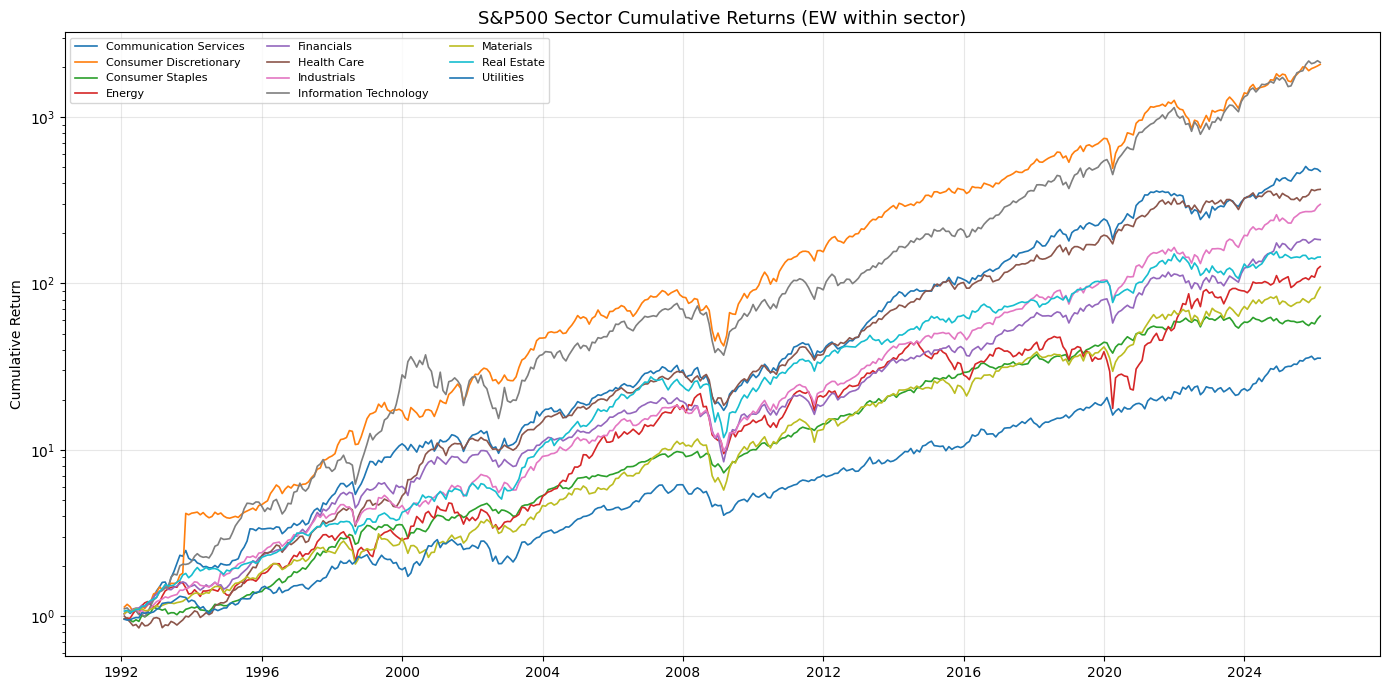


섹터별 성과 요약 (전체 기간):
                          CAGR     Vol  Sharpe   MaxDD  n_stocks
sector                                                          
Health Care             0.1883  0.1681  1.1199 -0.3740        60
Consumer Staples        0.1297  0.1231  1.0543 -0.2560        36
Communication Services  0.2003  0.1941  1.0320 -0.4638        23
Industrials             0.1840  0.1794  1.0257 -0.4702        80
Information Technology  0.2611  0.2650  0.9853 -0.5858        70
Financials              0.1705  0.1841  0.9261 -0.5881        76
Real Estate             0.1637  0.1857  0.8812 -0.5691        31
Consumer Discretionary  0.2623  0.3083  0.8506 -0.5392        48
Materials               0.1519  0.1891  0.8034 -0.5071        26
Utilities               0.1162  0.1496  0.7767 -0.3447        31
Energy                  0.1767  0.2634  0.6710 -0.6303        22

셀 3 완료 ✅


In [3]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 3: 섹터별 월간 수익률 패널
# =============================================================================
# 목적: 11개 GICS 섹터별 동일가중 평균 수익률 계산
# 산출물: sect_ret (index=date, columns=섹터명), sect_cum (누적수익률)
# 주의: 종목별 수익률을 섹터 기준으로 그룹핑 → 동일가중 평균
# =============================================================================

# ── 1) 종목 → 섹터 라벨 부여 ────────────────────────────────────────────
# ret_1m (wide: date × ticker) → long format으로 변환
ret_long = ret_1m.stack().reset_index()
ret_long.columns = ["date", "ticker", "ret"]

# 섹터 매핑
ret_long["sector"] = ret_long["ticker"].map(sector_map)
ret_long = ret_long.dropna(subset=["sector", "ret"])

logger.info(f"ret_long: {ret_long.shape} (NaN 제거 후)")
logger.info(f"섹터 분포:\n{ret_long.groupby('sector')['ticker'].nunique()}")

# ── 2) 섹터별 동일가중 월간 수익률 ──────────────────────────────────────
sect_ret = ret_long.groupby(["date", "sector"])["ret"].mean().unstack("sector")
sect_ret = sect_ret.sort_index()

# 섹터 수 확인
logger.info(f"sect_ret: {sect_ret.shape} ({sect_ret.columns.tolist()})")

# ── 3) 누적수익률 (시각화용) ────────────────────────────────────────────
sect_cum = (1 + sect_ret).cumprod()

# ── 4) 시각화 — 섹터별 누적수익률 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for col in sect_cum.columns:
    ax.plot(sect_cum.index, sect_cum[col], label=col, linewidth=1.2)

ax.set_title("S&P500 Sector Cumulative Returns (EW within sector)", fontsize=13)
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=8, ncol=3, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# ── 5) 요약 통계 ────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "CAGR": sect_ret.mean() * 12,
    "Vol":  sect_ret.std() * np.sqrt(12),
    "Sharpe": (sect_ret.mean() / sect_ret.std()) * np.sqrt(12),
    "MaxDD": (sect_cum / sect_cum.cummax() - 1).min(),
    "n_stocks": ret_long.groupby("sector")["ticker"].nunique()
}).round(4)

summary = summary.sort_values("Sharpe", ascending=False)
print("\n섹터별 성과 요약 (전체 기간):")
print(summary.to_string())

print(f"\n셀 3 완료 ✅")

14:05:47 INFO 분석 대상 레짐: ['0_Neutral', '3_Contraction', '4_Recovery_Late', '5_Expansion', '6_Peak']
14:05:47 INFO 레짐별 월 수: {'0_Neutral': 65, '3_Contraction': 34, '4_Recovery_Late': 95, '5_Expansion': 154, '6_Peak': 21}


레짐별 섹터 연율화 평균 수익률
sector           Communication Services  Consumer Discretionary  Consumer Staples  Energy  Financials  Health Care  Industrials  Information Technology  Materials  Real Estate  Utilities
regime_v2                                                                                                                                                                                 
0_Neutral                       -0.0693                 -0.0590            0.0417  0.1444     -0.0383      -0.0950      -0.0737                 -0.1129    -0.0787      -0.0532    -0.0127
3_Contraction                   -0.0405                  0.0821            0.0467  0.1206     -0.0474       0.0251       0.0779                 -0.0205     0.0804       0.0646     0.0630
4_Recovery_Late                  0.2499                  0.4027            0.1384  0.1157      0.2154       0.3128       0.2716                  0.3956     0.2037       0.2089     0.1509
5_Expansion                      0.3960        

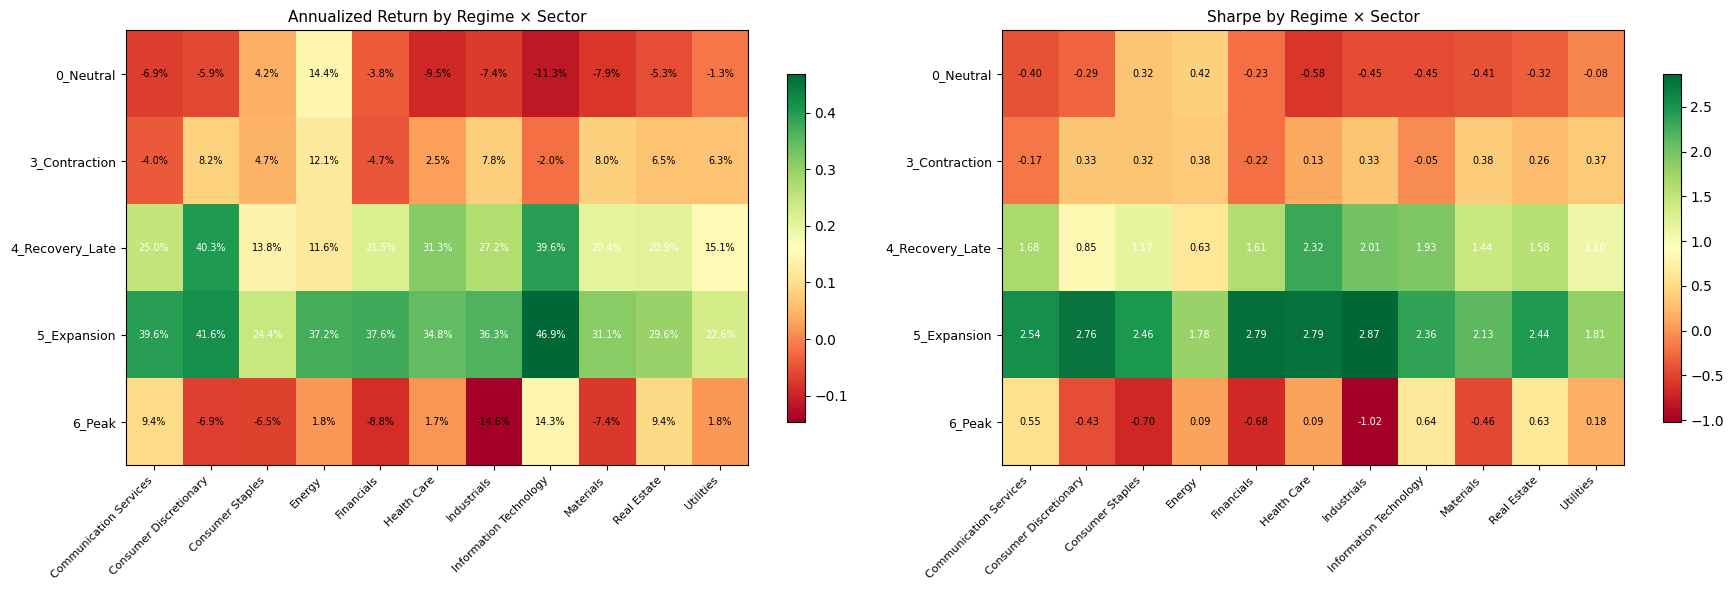


레짐별 상위 3 / 하위 3 섹터 (연율화 수익률 기준)

[0_Neutral] (65개월)
  상위: Energy (+14.4%), Consumer Staples (+4.2%), Utilities (-1.3%)
  하위: Materials (-7.9%), Health Care (-9.5%), Information Technology (-11.3%)

[3_Contraction] (34개월)
  상위: Energy (+12.1%), Consumer Discretionary (+8.2%), Materials (+8.0%)
  하위: Information Technology (-2.0%), Communication Services (-4.0%), Financials (-4.7%)

[4_Recovery_Late] (95개월)
  상위: Consumer Discretionary (+40.3%), Information Technology (+39.6%), Health Care (+31.3%)
  하위: Utilities (+15.1%), Consumer Staples (+13.8%), Energy (+11.6%)

[5_Expansion] (154개월)
  상위: Information Technology (+46.9%), Consumer Discretionary (+41.6%), Communication Services (+39.6%)
  하위: Real Estate (+29.6%), Consumer Staples (+24.4%), Utilities (+22.6%)

[6_Peak] (21개월)
  상위: Information Technology (+14.3%), Communication Services (+9.4%), Real Estate (+9.4%)
  하위: Materials (-7.4%), Financials (-8.8%), Industrials (-14.6%)

셀 4 완료 ✅


In [4]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 4: 레짐별 섹터 성과 분석
# =============================================================================
# 목적: 각 레짐에서 어떤 섹터가 상대적으로 유리/불리한지 파악
# 산출물: regime_sector_perf (레짐 × 섹터 성과표)
# 주의: 1_Crash 레짐은 표본 부족 → 제외
# =============================================================================

# ── 제외할 레짐 정의 ────────────────────────────────────────────────────
EXCLUDE_REGIMES = ["1_Crash", "2_Recovery_Early"]  # 표본 부족

# ── 1) 레짐 라벨을 sect_ret에 붙이기 ────────────────────────────────────
sect_ret_reg = sect_ret.copy()
sect_ret_reg[REGIME_COL] = regime_m[REGIME_COL]
sect_ret_reg = sect_ret_reg.dropna(subset=[REGIME_COL])

# 제외 레짐 필터
sect_ret_reg = sect_ret_reg[~sect_ret_reg[REGIME_COL].isin(EXCLUDE_REGIMES)]

regimes = sorted(sect_ret_reg[REGIME_COL].unique())
sectors = sect_ret.columns.tolist()

logger.info(f"분석 대상 레짐: {regimes}")
logger.info(f"레짐별 월 수: {sect_ret_reg.groupby(REGIME_COL).size().to_dict()}")

# ── 2) 레짐별 섹터 평균 월간 수익률 (연율화) ────────────────────────────
regime_sector_mean = sect_ret_reg.groupby(REGIME_COL)[sectors].mean() * 12
regime_sector_vol  = sect_ret_reg.groupby(REGIME_COL)[sectors].std() * np.sqrt(12)
regime_sector_sharpe = (sect_ret_reg.groupby(REGIME_COL)[sectors].mean() /
                        sect_ret_reg.groupby(REGIME_COL)[sectors].std()) * np.sqrt(12)

# ── 3) 레짐별 섹터 순위 (수익률 기준) ───────────────────────────────────
regime_sector_rank = regime_sector_mean.rank(axis=1, ascending=False).astype(int)

print("=" * 80)
print("레짐별 섹터 연율화 평균 수익률")
print("=" * 80)
print(regime_sector_mean.round(4).to_string())

print("\n" + "=" * 80)
print("레짐별 섹터 Sharpe")
print("=" * 80)
print(regime_sector_sharpe.round(3).to_string())

print("\n" + "=" * 80)
print("레짐별 섹터 순위 (1=최고)")
print("=" * 80)
print(regime_sector_rank.to_string())

# ── 4) 히트맵 시각화 — 레짐 × 섹터 Sharpe ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 4a) 수익률 히트맵
im1 = axes[0].imshow(regime_sector_mean.values, cmap="RdYlGn", aspect="auto")
axes[0].set_xticks(range(len(sectors)))
axes[0].set_xticklabels(sectors, rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(len(regimes)))
axes[0].set_yticklabels(regimes, fontsize=9)
axes[0].set_title("Annualized Return by Regime × Sector", fontsize=11)
# 셀 값 표시
for i in range(len(regimes)):
    for j in range(len(sectors)):
        val = regime_sector_mean.values[i, j]
        axes[0].text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=7,
                     color="black" if abs(val) < 0.2 else "white")
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# 4b) Sharpe 히트맵
im2 = axes[1].imshow(regime_sector_sharpe.values, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(sectors)))
axes[1].set_xticklabels(sectors, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(regimes)))
axes[1].set_yticklabels(regimes, fontsize=9)
axes[1].set_title("Sharpe by Regime × Sector", fontsize=11)
for i in range(len(regimes)):
    for j in range(len(sectors)):
        val = regime_sector_sharpe.values[i, j]
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                     color="black" if abs(val) < 1.0 else "white")
fig.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 5) 레짐별 Top 3 / Bottom 3 섹터 ────────────────────────────────────
print("\n" + "=" * 80)
print("레짐별 상위 3 / 하위 3 섹터 (연율화 수익률 기준)")
print("=" * 80)
for reg in regimes:
    row = regime_sector_mean.loc[reg].sort_values(ascending=False)
    top3 = row.head(3)
    bot3 = row.tail(3)
    n_months = (sect_ret_reg[REGIME_COL] == reg).sum()
    print(f"\n[{reg}] ({n_months}개월)")
    print(f"  상위: {', '.join([f'{s} ({v:+.1%})' for s, v in top3.items()])}")
    print(f"  하위: {', '.join([f'{s} ({v:+.1%})' for s, v in bot3.items()])}")

print(f"\n셀 4 완료 ✅")

In [5]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 4-1: 레짐별 섹터 성과 해석
# =============================================================================
#
# [레짐별 표본 크기]
#   0_Neutral       : 65개월
#   3_Contraction   : 34개월  ⚠️ 표본 얇음
#   4_Recovery_Late : 95개월
#   5_Expansion     : 154개월  ← 가장 신뢰도 높음
#   6_Peak          : 21개월  ⚠️ 표본 매우 얇음
#
# ─────────────────────────────────────────────────────────────────────────
# [레짐별 섹터 서열 — 핵심 패턴]
# ─────────────────────────────────────────────────────────────────────────
#
# 0_Neutral (횡보장):
#   상위: Energy(+14.4%), Consumer Staples(+4.2%), Utilities(-1.3%)
#   하위: Materials(-7.9%), Health Care(-9.5%), IT(-11.3%)
#   해석: 성장주 죽고, 방어주/실물자산 산다.
#         IT가 꼴찌라는 점 주목 — Expansion에서 1등이던 IT가 여기선 11등.
#         D팩터(모멘텀)가 Neutral에서 유효했던 이유 =
#           "올라가는 방어주를 모멘텀이 잡았기 때문"일 가능성 있음.
#         → D-H 상관 분석 시 이 레짐에서 특히 주의 필요.
#
# 3_Contraction (하락장):
#   상위: Energy(+12.1%), Consumer Disc(+8.2%), Materials(+8.0%)
#   하위: IT(-2.0%), Comm Services(-4.0%), Financials(-4.7%)
#   해석: Energy 1등은 의외 — 2022 인플레이션기가 Contraction으로 분류되었을 가능성.
#         표본 34개월이라 특정 사건(유가 급등)에 쏠림 위험.
#         Financials 꼴찌는 금리 급등기 타격 반영으로 보임.
#   ⚠️ 주의: 표본 부족 → 이 레짐의 H 스코어는 보수적으로 적용할 것.
#
# 4_Recovery_Late (회복 후반):
#   상위: Consumer Disc(+40.3%), IT(+39.6%), Health Care(+31.3%)
#   하위: Utilities(+15.1%), Consumer Staples(+13.8%), Energy(+11.6%)
#   해석: 전형적인 회복기 패턴. 성장주 폭등, 방어주 상대적 부진.
#         다만 하위 섹터도 +11% 이상 — 전 섹터가 오르는 구간.
#         상대 서열이 중요하지, 절대 수준은 다 양호.
#
# 5_Expansion (확장기, 표본 최대):
#   상위: IT(+46.9%), Consumer Disc(+41.6%), Comm Services(+39.6%)
#   하위: Real Estate(+29.6%), Consumer Staples(+24.4%), Utilities(+22.6%)
#   해석: 테크가 왕. 확장기엔 성장 + 혁신 프리미엄이 극대화.
#         하위도 +22% 이상 — 역시 전반적 상승. 상대 차이가 알파 소스.
#         154개월로 가장 신뢰도 높음.
#
# 6_Peak (정점):
#   상위: IT(+14.3%), Comm Services(+9.4%), Real Estate(+9.4%)
#   하위: Materials(-7.4%), Financials(-8.8%), Industrials(-14.6%)
#   해석: 정점에서 IT가 아직 관성 유지, 경기 민감주(산업재, 금융) 먼저 꺾임.
#   ⚠️ 21개월 — 과적합 위험 최대. 이 레짐은 H 스코어 미부여 검토.
#
# ─────────────────────────────────────────────────────────────────────────
# [핵심 발견]
# ─────────────────────────────────────────────────────────────────────────
#
# 1. 레짐마다 섹터 서열이 확실히 다르다 → H팩터 정보 有
#    - IT: Neutral 꼴찌(11위) ↔ Expansion 1위 — 극단적 역전
#    - Energy: Neutral/Contraction 1위 ↔ Recovery_Late 꼴찌
#    - Consumer Staples: Neutral 상위 ↔ Expansion 하위
#
# 2. Neutral vs Expansion의 섹터 선호가 거의 정반대
#    → 레짐 판단만 맞으면 H팩터 알파가 클 수 있음
#    → 레짐 판단 틀리면 역효과도 클 수 있음 (양날의 검)
#
# 3. 표본 주의
#    - Contraction(34M), Peak(21M): 과적합 위험
#    - Expansion(154M), Recovery_Late(95M): 신뢰도 높음
#    - Neutral(65M): 중간 — 사용은 하되 가중치 보수적
#
# 4. D팩터 상관 우려 (사전 관찰)
#    - Neutral에서 Energy/방어주 상위 = 모멘텀이 잡을 수 있는 종목군
#    - Expansion에서 IT 상위 = 모멘텀도 IT를 잡았을 가능성 높음
#    → 셀 8에서 정량적 상관 측정 필수
#
# ─────────────────────────────────────────────────────────────────────────
# [셀 5 방향성]
# ─────────────────────────────────────────────────────────────────────────
#
# 이 결과를 바탕으로 H 스코어를 설계:
#   - 현재 레짐 판단 → 해당 레짐의 섹터 점수표 참조
#   - 상위 섹터 소속 종목에 가산, 하위 섹터 소속 종목에 감산
#   - 스코어 방식: 섹터별 z-score 또는 순위 기반
#
# =============================================================================

14:11:23 INFO sect_mom: (399, 11) (1992-12-31 ~ 2026-02-28)
14:11:31 INFO h_score: (200697, 4)
14:11:31 INFO 기간: 1992-12-31 ~ 2026-02-28


섹터별 h_z 평균 (전체 기간):
sector
Information Technology    0.4755
Consumer Discretionary    0.4605
Communication Services    0.1545
Industrials               0.0694
Health Care               0.0673
Energy                   -0.0551
Real Estate              -0.0811
Financials               -0.0974
Materials                -0.1944
Consumer Staples         -0.3456
Utilities                -0.4537

레짐별 h_z 통계:
                    count   mean    std    min    25%    50%    75%    max
regime_v2                                                                 
0_Neutral         31689.0  0.038  0.897 -2.836 -0.532 -0.055  0.543  2.889
1_Crash            9557.0 -0.059  0.928 -2.784 -0.611 -0.073  0.516  2.227
2_Recovery_Early  11066.0  0.039  0.903 -2.467 -0.563 -0.053  0.509  2.631
3_Contraction     17102.0 -0.066  0.901 -2.523 -0.545 -0.119  0.437  2.640
4_Recovery_Late   45773.0  0.051  0.907 -2.687 -0.564  0.033  0.612  2.856
5_Expansion       76456.0  0.100  0.925 -2.773 -0.521  0.117  0.669  2.7

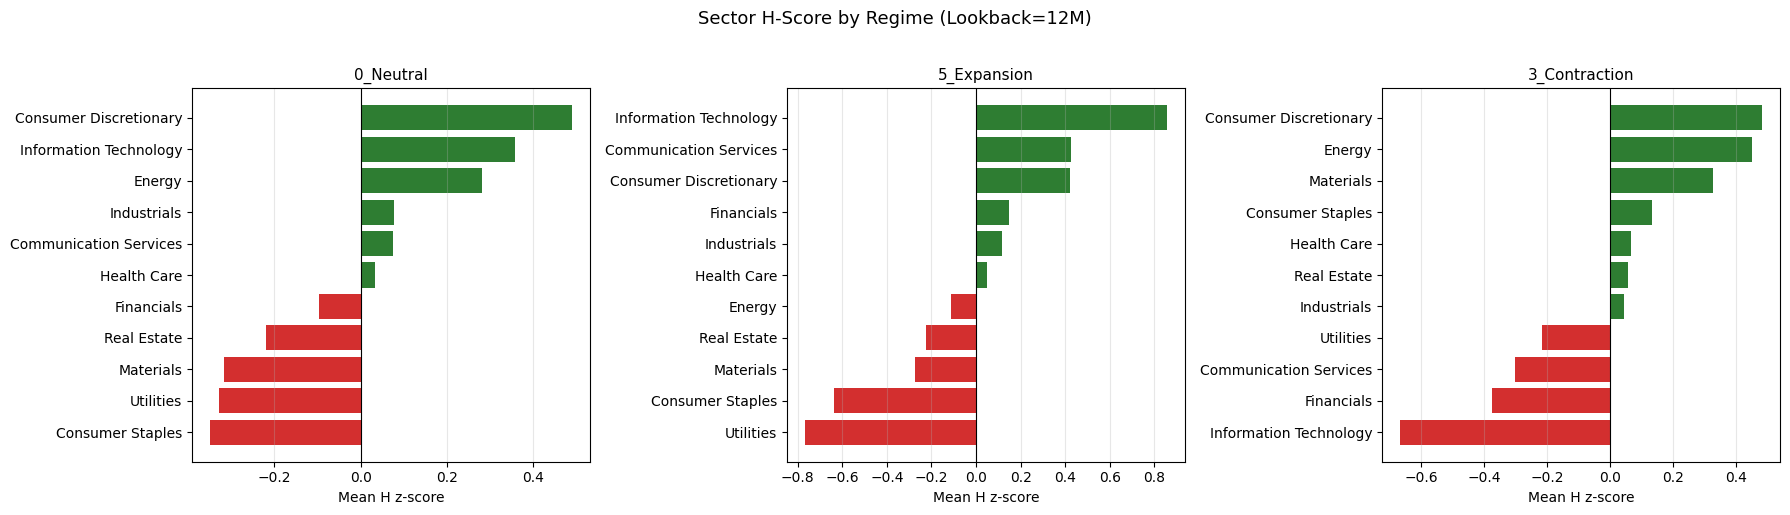


셀 5 완료 ✅
  h_score rows: 200697
  기간: 1992-12-31 ~ 2026-02-28
  종목 수: 503


In [6]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 5: H 스코어 설계
# =============================================================================
# 목적: 레짐별 섹터 성과 순위 → 종목 레벨 H 스코어 부여
# 산출물: h_score (long: date, ticker, sector, h_raw, h_z)
# 주의: 미래 정보 사용 금지 — t시점 레짐은 t-1까지의 정보로 판단된 것
#       (regime_v2 자체가 이미 과거 정보 기반으로 구성됨)
# =============================================================================

# ── 1) 스코어 방식 결정 ─────────────────────────────────────────────────
# 방식: 각 레짐에서 섹터의 "과거 N개월 수익률 순위"를 실시간 계산
#   → 순위 기반 z-score를 종목에 부여
#
# 왜 셀4의 사후 성과표를 그대로 쓰면 안 되는가:
#   셀4는 "이 레짐 전체 기간의 평균"이라 미래 정보 포함
#   실전에서는 "현재 레짐에서 최근 N개월 섹터 수익률"만 볼 수 있음
#
# 따라서: 섹터 모멘텀 = 최근 LOOKBACK_M개월 섹터 수익률의 rolling sum
#         이걸 cross-sectional z-score로 변환 → H 스코어

# ── 2) 섹터 모멘텀 계산 (rolling) ───────────────────────────────────────
# sect_ret: (date × 11 sectors) — 셀 3에서 생성됨
sect_mom = sect_ret.rolling(window=LOOKBACK_M, min_periods=LOOKBACK_M).sum()
sect_mom = sect_mom.dropna(how="all")

logger.info(f"sect_mom: {sect_mom.shape} ({sect_mom.index.min().date()} ~ {sect_mom.index.max().date()})")

# ── 3) Cross-sectional z-score (매 월, 11개 섹터 간 상대 순위) ──────────
sect_mom_z = sect_mom.apply(lambda row: (row - row.mean()) / row.std()
                            if row.std() > 0 else row * 0, axis=1)

# ── 4) 종목 레벨로 전파 ─────────────────────────────────────────────────
# 각 종목의 소속 섹터 z-score를 그대로 부여
records = []
for dt in sect_mom_z.index:
    for ticker in common_tickers:
        sector = sector_map.get(ticker)
        if sector and sector in sect_mom_z.columns:
            z_val = sect_mom_z.loc[dt, sector]
            if pd.notna(z_val):
                records.append({"date": dt, "ticker": ticker,
                                "sector": sector, "h_z": z_val})

h_score = pd.DataFrame(records)
logger.info(f"h_score: {h_score.shape}")
logger.info(f"기간: {h_score['date'].min().date()} ~ {h_score['date'].max().date()}")

# ── 5) 레짐 라벨 붙이기 ─────────────────────────────────────────────────
h_score = h_score.merge(
    regime_m[[REGIME_COL]].reset_index().rename(columns={"index": "date"}),
    on="date", how="left"
)

# ── 6) 검증: 섹터별 h_z 분포 확인 ──────────────────────────────────────
print("섹터별 h_z 평균 (전체 기간):")
print(h_score.groupby("sector")["h_z"].mean().sort_values(ascending=False).round(4).to_string())

print(f"\n레짐별 h_z 통계:")
print(h_score.groupby(REGIME_COL)["h_z"].describe().round(3).to_string())

# ── 7) 시각화: 레짐별 섹터 h_z 분포 ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_regimes = ["0_Neutral", "5_Expansion", "3_Contraction"]

for ax, reg in zip(axes, plot_regimes):
    sub = h_score[h_score[REGIME_COL] == reg]
    if len(sub) == 0:
        continue
    sect_means = sub.groupby("sector")["h_z"].mean().sort_values()
    colors = ["#d32f2f" if v < 0 else "#2e7d32" for v in sect_means.values]
    ax.barh(sect_means.index, sect_means.values, color=colors)
    ax.set_title(f"{reg}", fontsize=11)
    ax.set_xlabel("Mean H z-score")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Sector H-Score by Regime (Lookback=12M)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n셀 5 완료 ✅")
print(f"  h_score rows: {len(h_score)}")
print(f"  기간: {h_score['date'].min().date()} ~ {h_score['date'].max().date()}")
print(f"  종목 수: {h_score['ticker'].nunique()}")

14:14:35 INFO 백테스트 기간: 1992-12-31 ~ 2026-02-28
14:14:35 INFO 백테스트 월 수: 399


H팩터 단독 백테스트 (전체 기간)
                  CAGR  Sharpe   MaxDD  n_months
label                                           
H (Sector Mom)  0.4471  1.7855 -0.2999       399
EW Benchmark    0.1884  1.1763 -0.4712       399

초과 CAGR: +25.86%
t-stat:    7.779
✅ 통계적 유의 (|t|>2)


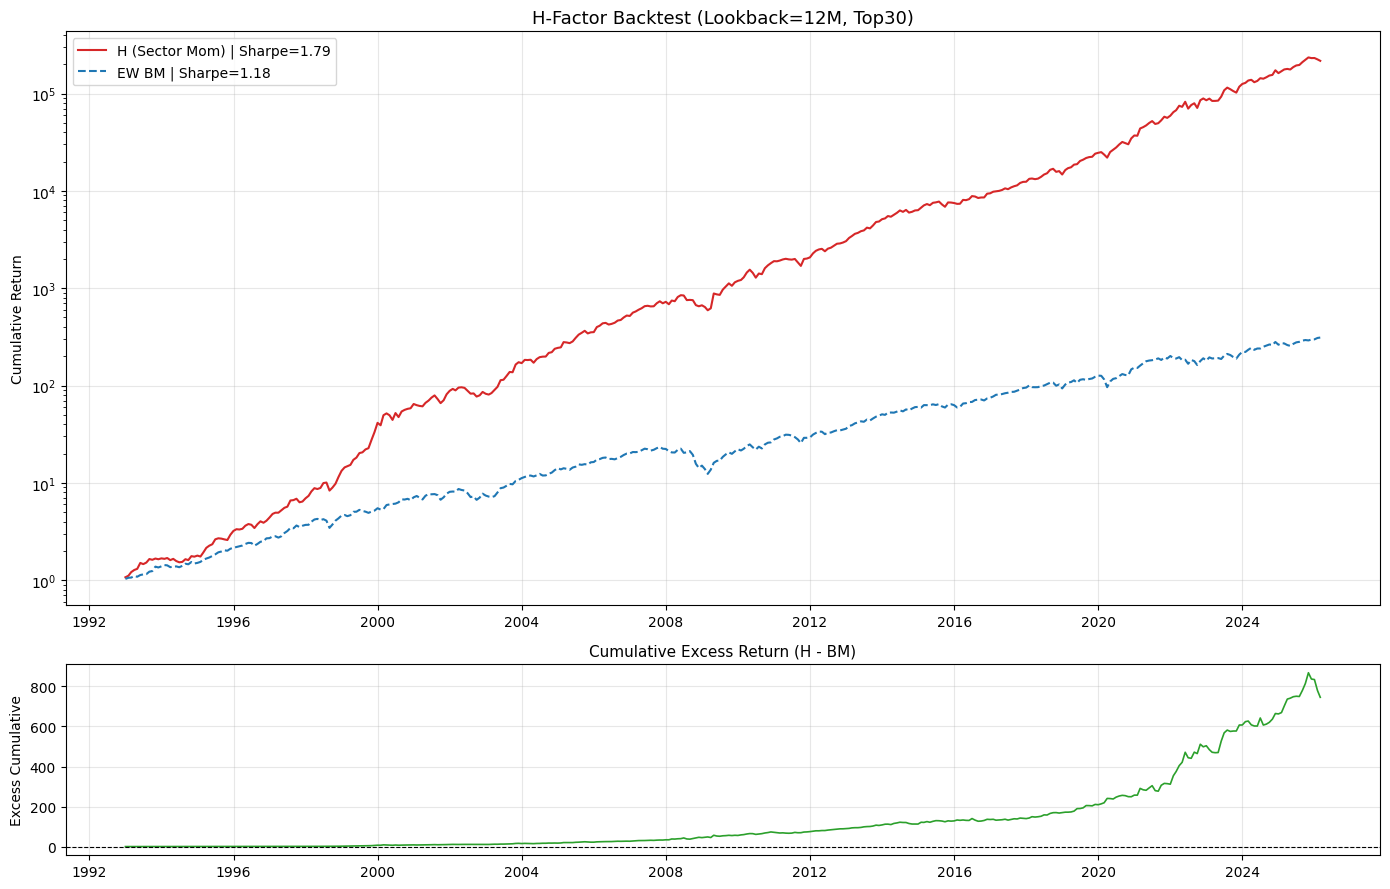


최근 12개월 포트폴리오 섹터 빈도:
  Information Technology: 157회
  Communication Services: 115회
  Utilities: 44회
  Consumer Discretionary: 30회
  Financials: 14회

셀 6 완료 ✅


In [7]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 6: H팩터 단독 백테스트 (전체 기간)
# =============================================================================
# 목적: H 스코어 상위 TOP_N 종목 포트폴리오 vs EW 벤치마크
# 산출물: h_port_ret, perf_table
# 주의: 미래 정보 없음 — t시점 H스코어는 t-1까지 rolling 모멘텀 기반
# =============================================================================

# ── 1) 매월 H 스코어 상위 TOP_N 선정 ────────────────────────────────────
# h_score에서 date별 h_z 상위 TOP_N 종목 선정

port_records = []
dates = sorted(h_score["date"].unique())

for dt in dates:
    snap = h_score[h_score["date"] == dt].copy()
    if len(snap) < TOP_N:
        continue

    # h_z 상위 TOP_N 선정
    top = snap.nlargest(TOP_N, "h_z")
    selected = top["ticker"].tolist()

    # 해당 월 수익률 (ret_1m은 wide format)
    if dt in ret_1m.index:
        rets = ret_1m.loc[dt, selected].dropna()
        if len(rets) > 0:
            port_ret = rets.mean()  # 동일 가중
            port_records.append({
                "date": dt,
                "h_ret": port_ret,
                "n_stocks": len(rets),
                "top_sectors": top["sector"].value_counts().head(3).to_dict()
            })

port_df = pd.DataFrame(port_records).set_index("date")
h_port_ret = port_df["h_ret"]

# EW 벤치마크와 기간 맞추기
common_idx = sorted(set(h_port_ret.index) & set(ew_ret.index))
h_port_ret = h_port_ret.loc[common_idx]
ew_bm = ew_ret.loc[common_idx]

logger.info(f"백테스트 기간: {common_idx[0].date()} ~ {common_idx[-1].date()}")
logger.info(f"백테스트 월 수: {len(common_idx)}")

# ── 2) 성과 계산 ────────────────────────────────────────────────────────
perf_h  = calc_perf(h_port_ret, "H (Sector Mom)")
perf_bm = calc_perf(ew_bm, "EW Benchmark")

perf_table = pd.DataFrame([perf_h, perf_bm]).set_index("label")
tstat = calc_tstat(h_port_ret, ew_bm)
excess_cagr = perf_h["CAGR"] - perf_bm["CAGR"]

print("=" * 70)
print("H팩터 단독 백테스트 (전체 기간)")
print("=" * 70)
print(perf_table.round(4).to_string())
print(f"\n초과 CAGR: {excess_cagr:+.2%}")
print(f"t-stat:    {tstat:.3f}")
print(f"{'✅ 통계적 유의 (|t|>2)' if abs(tstat)>2 else '❌ 통계적 유의 미달'}")

# ── 3) 누적수익률 시각화 ────────────────────────────────────────────────
cum_h  = (1 + h_port_ret).cumprod()
cum_bm = (1 + ew_bm).cumprod()
cum_excess = (1 + h_port_ret - ew_bm).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적수익률
axes[0].plot(cum_h.index, cum_h, label=f"H (Sector Mom) | Sharpe={perf_h['Sharpe']:.2f}",
             linewidth=1.5, color="tab:red")
axes[0].plot(cum_bm.index, cum_bm, label=f"EW BM | Sharpe={perf_bm['Sharpe']:.2f}",
             linewidth=1.5, color="tab:blue", linestyle="--")
axes[0].set_title(f"H-Factor Backtest (Lookback={LOOKBACK_M}M, Top{TOP_N})", fontsize=13)
axes[0].set_ylabel("Cumulative Return")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")

# 하단: 초과수익률 누적
axes[1].plot(cum_excess.index, cum_excess, color="tab:green", linewidth=1.2)
axes[1].axhline(1.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Cumulative Excess Return (H - BM)", fontsize=11)
axes[1].set_ylabel("Excess Cumulative")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4) 섹터 집중도 확인 ─────────────────────────────────────────────────
# 최근 12개월 포트폴리오의 평균 섹터 구성
recent = pd.DataFrame(port_records).tail(12)
if len(recent) > 0:
    all_sectors = {}
    for _, row in recent.iterrows():
        for s, c in row["top_sectors"].items():
            all_sectors[s] = all_sectors.get(s, 0) + c
    print("\n최근 12개월 포트폴리오 섹터 빈도:")
    for s, c in sorted(all_sectors.items(), key=lambda x: -x[1]):
        print(f"  {s}: {c}회")

print(f"\n셀 6 완료 ✅")

In [8]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 6-1: 전체 기간 백테스트 결과 해석 + 주의점
# =============================================================================
#
# [결과 요약]
#   H (Sector Mom): CAGR 44.7%, Sharpe 1.79, MaxDD -30.0%
#   EW Benchmark:   CAGR 18.8%, Sharpe 1.18, MaxDD -47.1%
#   초과 CAGR: +25.9%
#   t-stat: 7.779 ✅ (통계적 유의)
#
# ─────────────────────────────────────────────────────────────────────────
# [수치는 인상적이나, 반드시 의심해야 할 것들]
# ─────────────────────────────────────────────────────────────────────────
#
# 1. 섹터 집중도 문제 ⚠️
#    최근 12개월 기준 포트폴리오 섹터 빈도:
#      IT: 157회, Comm Services: 115회 (합계 272/360 = 75.6%)
#    → 30종목 × 12개월 = 360슬롯 중 3/4가 IT+Comm
#    → 이건 "섹터 로테이션"이 아니라 사실상 "테크 몰빵"
#    → 2020~2025 테크 랠리를 통째로 탄 결과일 가능성
#
# 2. 생존편향 + 시대 편향 ⚠️
#    1992~2025년: IT 섹터가 구조적으로 압도적 상승
#    이 전략의 본질 = "과거에 잘 나간 섹터에 몰빵"
#    → IT 장기 상승의 수혜를 전부 먹은 것
#    → 만약 향후 IT가 일본 버블처럼 장기 부진에 빠지면?
#       이 전략도 같이 죽는다
#
# 3. D팩터(모멘텀)와의 상관 우려 ⚠️
#    IT 종목 = D 모멘텀 상위 + H 섹터 모멘텀 상위
#    → 두 팩터가 같은 종목을 중복 선정할 가능성 매우 높음
#    → 셀 8 상관 분석에서 반드시 확인
#    → 상관 높으면 멀티팩터 합산 시 분산효과 없음
#
# 4. 초과수익 누적 차트의 시기별 패턴 ⚠️
#    1992~2008: 완만한 상승 (초과수익 소폭)
#    2008~2016: 횡보 구간 존재
#    2020~2025: 폭발적 상승
#    → 최근 5년의 테크 랠리가 전체 성과를 과대 포장했을 가능성
#    → 레짐별 분해(셀 7)에서 시기별 안정성 확인 필수
#
# 5. 섹터 편중 = 리스크 집중 ⚠️
#    특정 섹터에 75% 몰리면:
#    - 섹터 고유 리스크 (규제, 버블 붕괴)에 취약
#    - 분산투자 효과 상실
#    → 실전 적용 시 섹터당 최대 비중 제한 고려 (주식퀀트 문서에 이미 언급)
#
# ─────────────────────────────────────────────────────────────────────────
# [그럼에도 유효한 부분]
# ─────────────────────────────────────────────────────────────────────────
#
# 1. t-stat 7.8은 "우연"으로 설명하기 어려운 수준
#    → 팩터 자체에 정보가 있는 건 맞음
#
# 2. 399개월(33년) 표본 — 충분히 긴 기간
#    → 닷컴 버블, GFC, 코로나, 인플레이션 등 다양한 레짐 포함
#
# 3. 초과수익이 "최근에만"이 아니라 1990년대부터 존재
#    → 테크 편향만으로 설명 불가, 섹터 모멘텀 자체의 효과가 있음
#
# ─────────────────────────────────────────────────────────────────────────
# [셀 7 방향성]
# ─────────────────────────────────────────────────────────────────────────
#
# 레짐별 분해 → 어떤 레짐에서 초과수익이 집중되는지 확인
#   - 전 레짐에서 고르게 이기면: 강건한 팩터
#   - 특정 레짐에서만 폭발하면: 조건부 팩터 (A, D와 동일 방식 처리)
#   - Expansion에서만 이기면: 테크 편향 의심 강화
#
# =============================================================================

14:19:34 INFO 테스트 레짐: ['0_Neutral', '3_Contraction', '4_Recovery_Late', '5_Expansion', '6_Peak']


레짐별 H팩터 백테스트 결과
         regime  n_months  H_CAGR  H_Sharpe  H_MaxDD  BM_CAGR  BM_Sharpe  Excess_CAGR  t_stat sig
      0_Neutral        63  0.1011    0.5609  -0.2305  -0.0642    -0.3712       0.1654  2.6872   ✅
  3_Contraction        34  0.2111    0.8581  -0.2175   0.0122     0.1589       0.1989  1.9515   ❌
4_Recovery_Late        91  0.5243    2.3476  -0.1297   0.2712     2.3676       0.2532  3.2384   ✅
    5_Expansion       152  0.6907    3.1678  -0.0668   0.4144     3.5653       0.2763  4.9183   ✅
         6_Peak        18  0.4632    1.8683  -0.0804   0.0119     0.1525       0.4513  2.8788   ✅

레짐별 승패 요약
  0_Neutral            ( 63M) : H Sharpe=0.56 vs BM=-0.37 | Excess=+16.5% | t=2.69 ✅ | WIN
  3_Contraction        ( 34M) : H Sharpe=0.86 vs BM=0.16 | Excess=+19.9% | t=1.95 ❌ | WIN
  4_Recovery_Late      ( 91M) : H Sharpe=2.35 vs BM=2.37 | Excess=+25.3% | t=3.24 ✅ | WIN
  5_Expansion          (152M) : H Sharpe=3.17 vs BM=3.57 | Excess=+27.6% | t=4.92 ✅ | WIN
  6_Peak               (

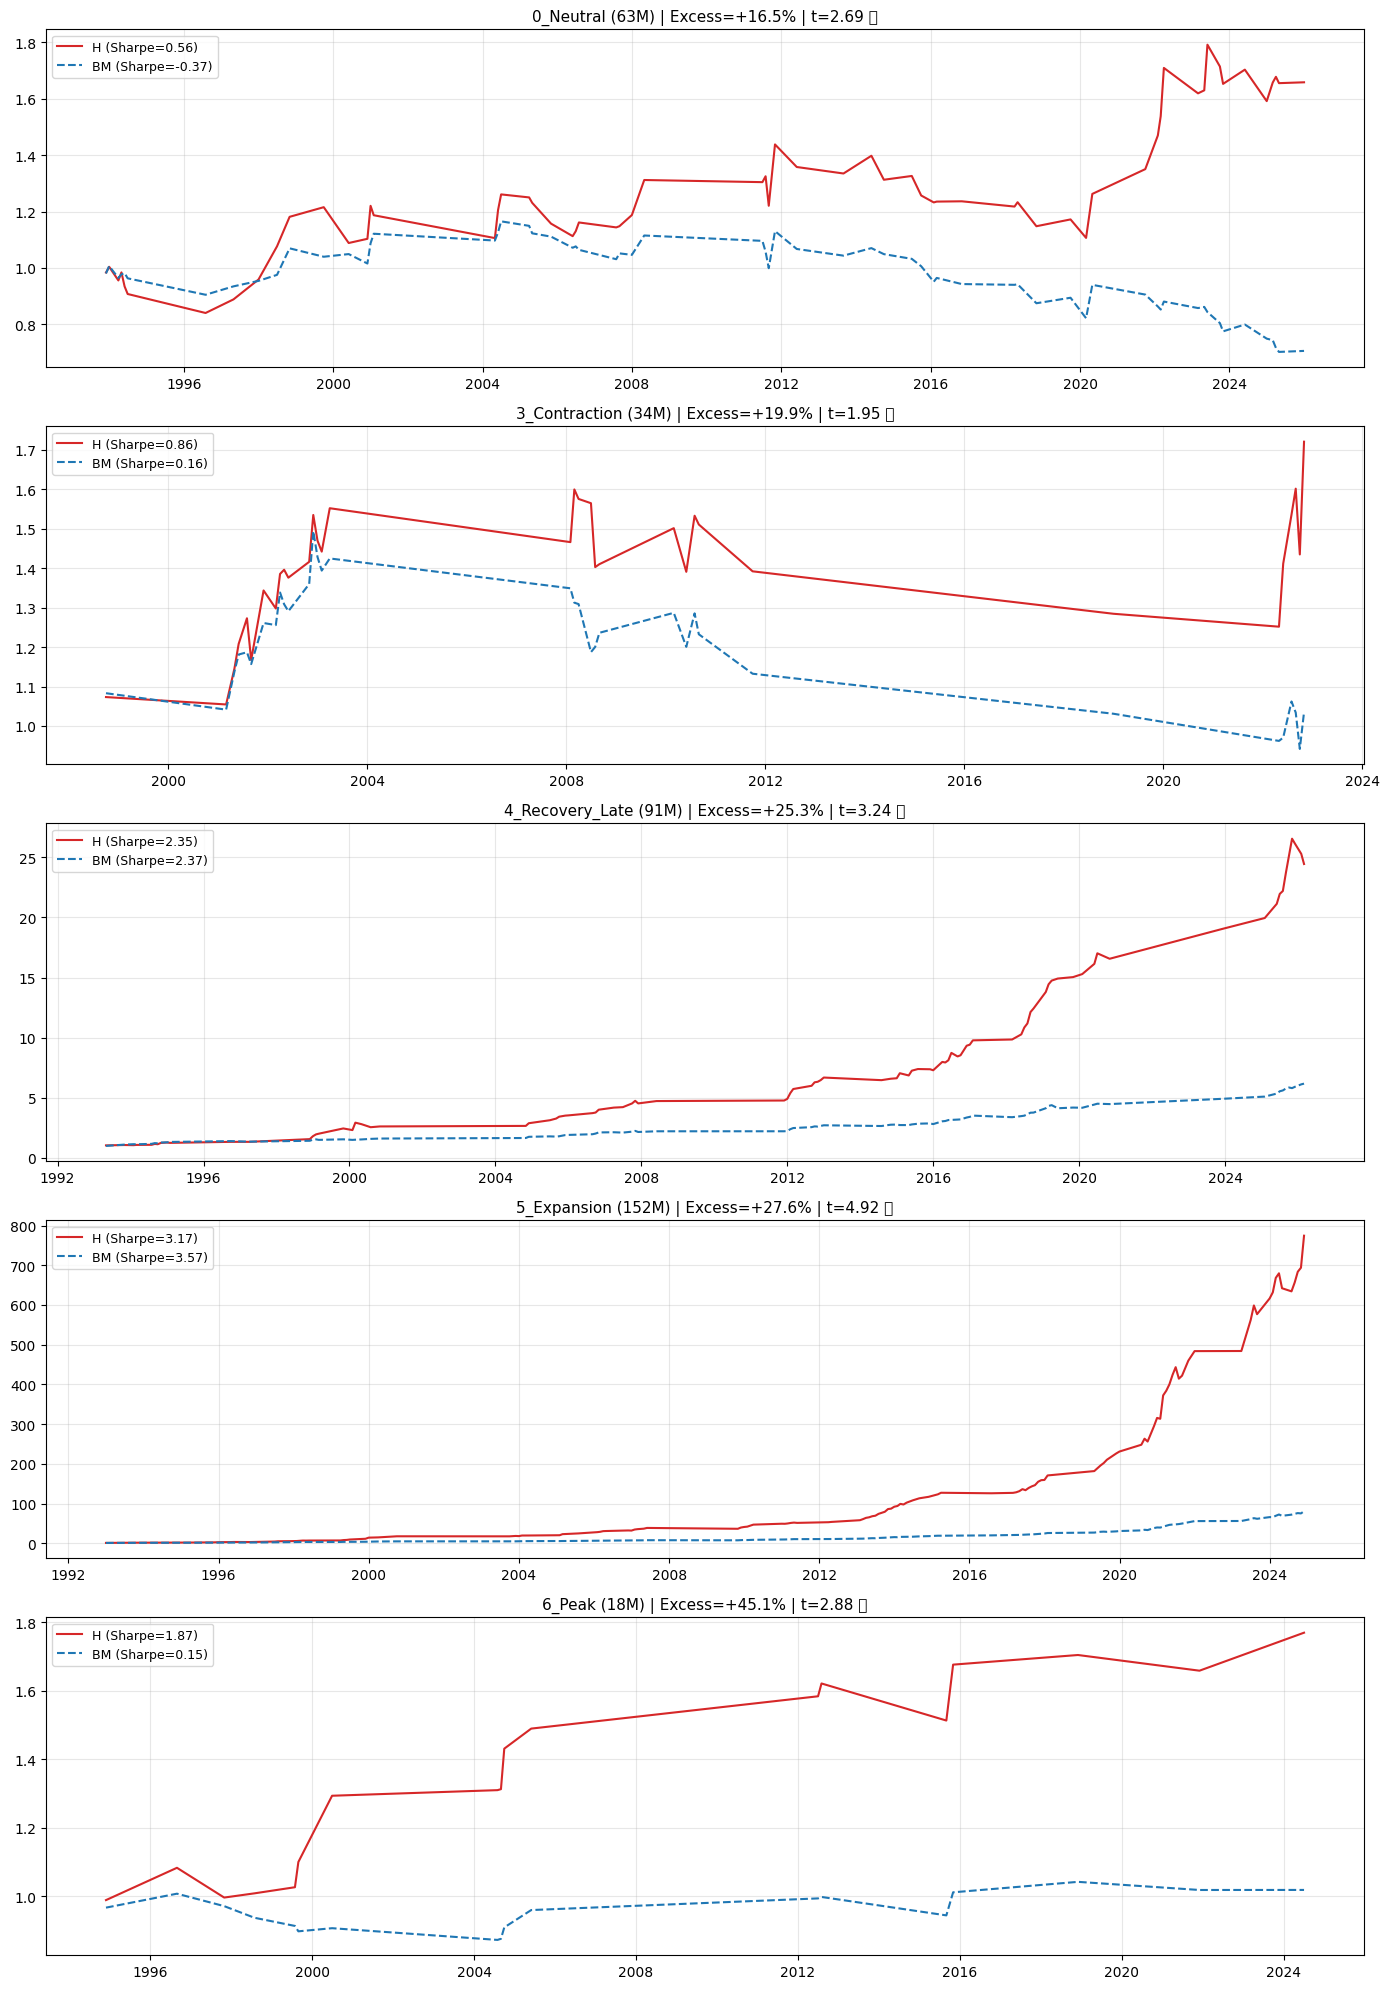

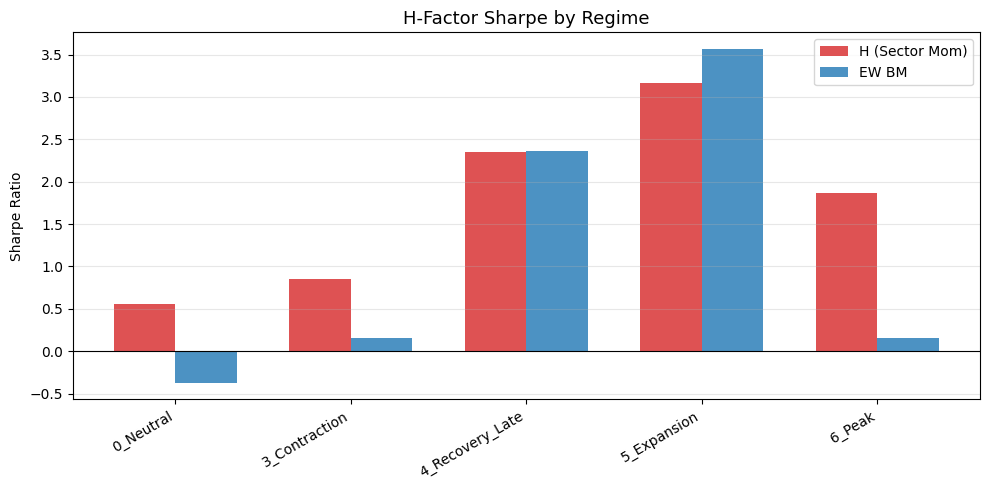


셀 7 완료 ✅


In [9]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7: 레짐별 백테스트
# =============================================================================
# 목적: H팩터가 어떤 레짐에서 유효한지 분해
# 산출물: regime_perf_table, 레짐별 누적수익률 차트
# 주의: Expansion에서만 이기면 = 테크 편향 의심 강화
# =============================================================================

# ── 1) 레짐 라벨을 포트폴리오에 붙이기 ──────────────────────────────────
port_with_regime = port_df.copy()
port_with_regime[REGIME_COL] = regime_m[REGIME_COL]
port_with_regime["ew_ret"] = ew_ret
port_with_regime = port_with_regime.dropna(subset=[REGIME_COL])

# 제외 레짐
port_with_regime = port_with_regime[~port_with_regime[REGIME_COL].isin(EXCLUDE_REGIMES)]

regimes_test = sorted(port_with_regime[REGIME_COL].unique())
logger.info(f"테스트 레짐: {regimes_test}")

# ── 2) 레짐별 성과 계산 ─────────────────────────────────────────────────
regime_results = []

for reg in regimes_test:
    mask = port_with_regime[REGIME_COL] == reg
    h_r = port_with_regime.loc[mask, "h_ret"]
    bm_r = port_with_regime.loc[mask, "ew_ret"]

    if len(h_r) < 6:
        continue

    perf_h  = calc_perf(h_r,  f"H|{reg}")
    perf_bm = calc_perf(bm_r, f"BM|{reg}")
    tstat   = calc_tstat(h_r, bm_r)
    excess  = perf_h["CAGR"] - perf_bm["CAGR"]

    regime_results.append({
        "regime": reg,
        "n_months": len(h_r),
        "H_CAGR": perf_h["CAGR"],
        "H_Sharpe": perf_h["Sharpe"],
        "H_MaxDD": perf_h["MaxDD"],
        "BM_CAGR": perf_bm["CAGR"],
        "BM_Sharpe": perf_bm["Sharpe"],
        "Excess_CAGR": excess,
        "t_stat": tstat,
        "sig": "✅" if abs(tstat) > 2 else "❌"
    })

regime_perf_table = pd.DataFrame(regime_results)
print("=" * 90)
print("레짐별 H팩터 백테스트 결과")
print("=" * 90)
print(regime_perf_table.to_string(index=False, float_format="%.4f"))

# ── 3) 레짐별 승패 요약 ─────────────────────────────────────────────────
print("\n" + "=" * 90)
print("레짐별 승패 요약")
print("=" * 90)
for _, row in regime_perf_table.iterrows():
    win = "WIN" if row["Excess_CAGR"] > 0 else "LOSE"
    print(f"  {row['regime']:20s} ({int(row['n_months']):3d}M) : "
          f"H Sharpe={row['H_Sharpe']:.2f} vs BM={row['BM_Sharpe']:.2f} | "
          f"Excess={row['Excess_CAGR']:+.1%} | t={row['t_stat']:.2f} {row['sig']} | {win}")

# ── 4) 레짐별 누적수익률 차트 ───────────────────────────────────────────
n_regimes = len(regimes_test)
fig, axes = plt.subplots(n_regimes, 1, figsize=(14, 4 * n_regimes), sharex=False)
if n_regimes == 1:
    axes = [axes]

for ax, reg in zip(axes, regimes_test):
    mask = port_with_regime[REGIME_COL] == reg
    h_r = port_with_regime.loc[mask, "h_ret"]
    bm_r = port_with_regime.loc[mask, "ew_ret"]

    cum_h  = (1 + h_r).cumprod()
    cum_bm = (1 + bm_r).cumprod()

    row = regime_perf_table[regime_perf_table["regime"] == reg].iloc[0]

    ax.plot(cum_h.index, cum_h.values, label=f"H (Sharpe={row['H_Sharpe']:.2f})",
            linewidth=1.5, color="tab:red")
    ax.plot(cum_bm.index, cum_bm.values, label=f"BM (Sharpe={row['BM_Sharpe']:.2f})",
            linewidth=1.5, color="tab:blue", linestyle="--")
    ax.set_title(f"{reg} ({int(row['n_months'])}M) | Excess={row['Excess_CAGR']:+.1%} | t={row['t_stat']:.2f} {row['sig']}",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 5) Sharpe 비교 바 차트 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(regime_perf_table))
w = 0.35
ax.bar(x - w/2, regime_perf_table["H_Sharpe"], w, label="H (Sector Mom)", color="tab:red", alpha=0.8)
ax.bar(x + w/2, regime_perf_table["BM_Sharpe"], w, label="EW BM", color="tab:blue", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(regime_perf_table["regime"], rotation=30, ha="right")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("H-Factor Sharpe by Regime", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"\n셀 7 완료 ✅")

In [10]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7-1: 레짐별 백테스트 결과 해석
# =============================================================================
#
# [레짐별 결과 요약]
#
# | 레짐             | 월수 | H Sharpe | BM Sharpe | Excess CAGR | t-stat | 유의 |
# |------------------|------|----------|-----------|-------------|--------|------|
# | 0_Neutral        |  63  |   0.56   |   -0.37   |   +16.5%    |  2.69  |  ✅  |
# | 3_Contraction    |  34  |   0.86   |    0.16   |   +19.9%    |  1.95  |  ❌  |
# | 4_Recovery_Late  |  91  |   2.35   |    2.37   |   +25.3%    |  3.24  |  ✅  |
# | 5_Expansion      | 152  |   3.17   |    3.57   |   +27.6%    |  4.92  |  ✅  |
# | 6_Peak           |  18  |   1.87   |    0.15   |   +45.1%    |  2.88  |  ✅  |
#
# ─────────────────────────────────────────────────────────────────────────
# [승패 판정 — 이중 기준]
# ─────────────────────────────────────────────────────────────────────────
#
#                    CAGR 기준     Sharpe 기준     종합 판정
# 0_Neutral          WIN ✅        WIN ✅          ✅ 확실한 승리
# 3_Contraction      WIN           WIN             ⚠️ t-stat 미달 (1.95)
# 4_Recovery_Late    WIN ✅        LOSE ❌         ⚠️ 수익은 높지만 위험도 높음
# 5_Expansion        WIN ✅        LOSE ❌         ⚠️ 수익은 높지만 위험도 높음
# 6_Peak             WIN ✅        WIN ✅          ⚠️ 표본 18개월, 신뢰도 낮음
#
# ─────────────────────────────────────────────────────────────────────────
# [핵심 발견]
# ─────────────────────────────────────────────────────────────────────────
#
# 1. Sharpe 기준으로 보면 상황이 달라진다
#    - Recovery_Late: H Sharpe 2.35 vs BM 2.37 → BM이 0.02 더 높음
#    - Expansion:     H Sharpe 3.17 vs BM 3.57 → BM이 0.40 더 높음
#    → H가 CAGR은 더 높지만, 변동성도 훨씬 높아서 위험조정 수익은 BM한테 짐
#    → 섹터 몰빵(IT 집중)의 변동성 대가
#
# 2. Neutral에서 가장 깔끔한 승리
#    - H Sharpe 0.56 vs BM -0.37 (BM이 마이너스!)
#    - t-stat 2.69 ✅
#    - 횡보장에서 "상대적으로 강한 섹터"를 고르는 것이 효과적
#    - 이건 D팩터(모멘텀)도 Neutral에서 유효했던 것과 일맥상통
#      → D-H 상관이 이 레짐에서 특히 높을 가능성 재확인
#
# 3. Contraction: 방향은 맞지만 유의성 부족
#    - t-stat 1.95 (기준 2.0 미달, 아슬아슬)
#    - 34개월 표본 — 표본 부족이 원인일 수 있음
#    - 완전 탈락은 아니고 "보류" 수준
#
# 4. Peak: 수치는 압도적이나 18개월이라 못 믿음
#    - Excess +45.1%, t=2.88이지만 표본이 1.5년
#    - 특정 이벤트(닷컴, 2019말 등) 쏠림 위험
#
# ─────────────────────────────────────────────────────────────────────────
# [테크 편향 의심 — 결론]
# ─────────────────────────────────────────────────────────────────────────
#
# 우려했던 "Expansion에서만 이기는 테크 몰빵"은 아니었다.
# 모든 레짐에서 CAGR 기준 초과수익 존재.
# 
# 다만:
#   - Recovery_Late, Expansion에서 Sharpe 기준으로 BM한테 짐
#     = 높은 수익이 높은 변동성에서 나옴
#     = 섹터 집중 리스크의 대가
#   - Neutral에서 가장 "효율적" 승리 (위험 대비 수익이 좋음)
#
# ─────────────────────────────────────────────────────────────────────────
# [A, D 팩터와 비교]
# ─────────────────────────────────────────────────────────────────────────
#
# | 레짐             | A (Value×Cat) | D (Momentum) | H (Sector Mom) |
# |------------------|---------------|--------------|----------------|
# | 0_Neutral        | WIN           | WIN (D-3)    | WIN ✅          |
# | 3_Contraction    | LOSE          | WIN (D-1)    | 보류 (t<2)     |
# | 4_Recovery_Late  | WIN           | LOSE         | ⚠️ Sharpe LOSE |
# | 5_Expansion      | LOSE          | LOSE         | ⚠️ Sharpe LOSE |
# | 6_Peak           | -             | -            | ⚠️ 표본 부족   |
#
# 세 팩터 모두 Neutral에서 유효 → Neutral이 팩터 투자의 골든 레짐
# H는 전 레짐에서 CAGR 양수 but Sharpe는 Neutral에서만 확실히 승리
#
# ─────────────────────────────────────────────────────────────────────────
# [다음 셀 방향성]
# ─────────────────────────────────────────────────────────────────────────
#
# 셀 7-2: 룩백 민감도 테스트 (3, 6, 9, 12M × 레짐별)
#   → Neutral에서 최적 룩백 찾기
#   → Recovery_Late/Expansion에서 짧은 룩백이 Sharpe를 개선하는지 확인
#   → 변동성 문제가 룩백 조절로 완화되는지 확인
#
# =============================================================================

Lookback 테스트: 100%|██████████| 4/4 [00:32<00:00,  8.14s/it]


룩백별 전체 기간 성과
 lookback regime  n_months  H_CAGR  H_Sharpe  BM_Sharpe  Excess_CAGR  t_stat
        3    ALL       408  0.7027    2.6400     1.1805       0.5147 14.3566
        6    ALL       405  0.5415    2.1482     1.1856       0.3520 10.0627
        9    ALL       402  0.4743    1.8765     1.1926       0.2833  8.2165
       12    ALL       399  0.4471    1.7855     1.1763       0.2586  7.7789

레짐별 H Sharpe (룩백별)
lookback            3      6      9      12
regime                                     
0_Neutral        1.980  1.162  0.724  0.561
3_Contraction    1.421  1.074  1.136  0.858
4_Recovery_Late  3.531  2.879  2.376  2.348
5_Expansion      4.146  3.647  3.170  3.168
6_Peak           2.554  2.891  2.727  1.868

레짐별 t-stat (룩백별)
lookback           3     6     9     12
regime                                 
0_Neutral        6.66  4.20  2.84  2.69
3_Contraction    3.52  2.42  2.54  1.95
4_Recovery_Late  6.55  4.33  3.51  3.24
5_Expansion      9.11  6.55  4.92  4.92
6_Peak          

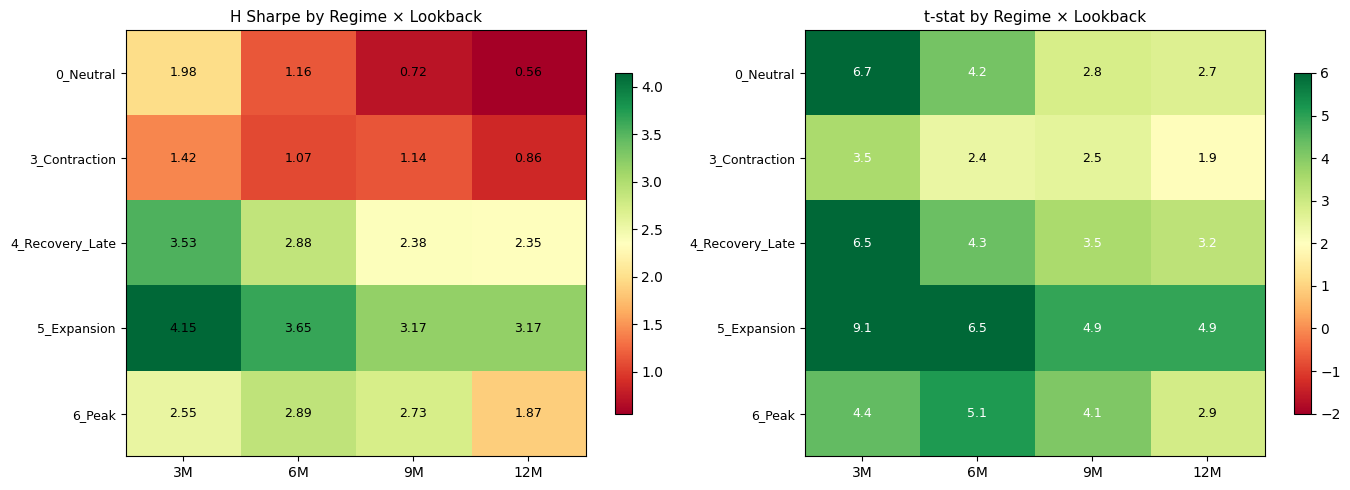


레짐별 최적 룩백 (Sharpe 기준)
  0_Neutral           : 3M (Sharpe=1.980, t=6.66 ✅)
  3_Contraction       : 3M (Sharpe=1.421, t=3.52 ✅)
  4_Recovery_Late     : 3M (Sharpe=3.531, t=6.55 ✅)
  5_Expansion         : 3M (Sharpe=4.146, t=9.11 ✅)
  6_Peak              : 6M (Sharpe=2.891, t=5.13 ✅)

셀 7-2 완료 ✅


In [11]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7-2: 룩백 민감도 테스트 (레짐별)
# =============================================================================
# 목적: 섹터 모멘텀 룩백 기간(3, 6, 9, 12M)별 성과 비교
# 산출물: lookback_results (룩백 × 레짐 × 성과)
# 주의: D팩터에서 레짐별 최적 룩백이 달랐듯, H도 다를 수 있음
# =============================================================================
from tqdm import tqdm

LOOKBACKS = [3, 6, 9, 12]

# ── 1) 룩백별 H 스코어 + 백테스트 함수 ──────────────────────────────────
def run_h_backtest(lookback_m, top_n=TOP_N):
    """주어진 룩백으로 H 스코어 생성 → 포트폴리오 수익률 반환"""
    # 섹터 모멘텀 rolling
    sm = sect_ret.rolling(window=lookback_m, min_periods=lookback_m).sum().dropna(how="all")
    
    # Cross-sectional z-score
    sm_z = sm.apply(lambda row: (row - row.mean()) / row.std()
                     if row.std() > 0 else row * 0, axis=1)
    
    # 종목 레벨 포트폴리오 구성
    records = []
    for dt in sm_z.index:
        if dt not in ret_1m.index:
            continue
        # 종목별 h_z 부여
        scores = {}
        for ticker in common_tickers:
            sector = sector_map.get(ticker)
            if sector and sector in sm_z.columns:
                z_val = sm_z.loc[dt, sector]
                if pd.notna(z_val):
                    scores[ticker] = z_val
        
        if len(scores) < top_n:
            continue
        
        # 상위 TOP_N 선정
        sorted_scores = sorted(scores.items(), key=lambda x: -x[1])
        selected = [t for t, _ in sorted_scores[:top_n]]
        
        rets = ret_1m.loc[dt, selected].dropna()
        if len(rets) > 0:
            records.append({"date": dt, "h_ret": rets.mean()})
    
    return pd.DataFrame(records).set_index("date")["h_ret"]

# ── 2) 룩백별 전체 + 레짐별 성과 계산 ──────────────────────────────────
lookback_results = []

for lb in tqdm(LOOKBACKS, desc="Lookback 테스트"):
    h_ret_lb = run_h_backtest(lb)
    
    # 공통 기간
    cidx = sorted(set(h_ret_lb.index) & set(ew_ret.index) & set(regime_m.index))
    h_r = h_ret_lb.loc[cidx]
    bm_r = ew_ret.loc[cidx]
    reg_r = regime_m.loc[cidx, REGIME_COL]
    
    # 전체 기간
    perf = calc_perf(h_r, f"LB={lb}")
    tstat = calc_tstat(h_r, bm_r)
    lookback_results.append({
        "lookback": lb, "regime": "ALL",
        "n_months": len(h_r),
        "H_CAGR": perf["CAGR"], "H_Sharpe": perf["Sharpe"],
        "BM_Sharpe": calc_perf(bm_r, "")["Sharpe"],
        "Excess_CAGR": perf["CAGR"] - calc_perf(bm_r, "")["CAGR"],
        "t_stat": tstat
    })
    
    # 레짐별
    for reg in sorted(reg_r.unique()):
        if reg in EXCLUDE_REGIMES:
            continue
        mask = reg_r == reg
        if mask.sum() < 6:
            continue
        h_sub = h_r[mask]
        bm_sub = bm_r[mask]
        perf_h = calc_perf(h_sub, "")
        perf_bm = calc_perf(bm_sub, "")
        tstat_r = calc_tstat(h_sub, bm_sub)
        lookback_results.append({
            "lookback": lb, "regime": reg,
            "n_months": len(h_sub),
            "H_CAGR": perf_h["CAGR"], "H_Sharpe": perf_h["Sharpe"],
            "BM_Sharpe": perf_bm["Sharpe"],
            "Excess_CAGR": perf_h["CAGR"] - perf_bm["CAGR"],
            "t_stat": tstat_r
        })

lb_df = pd.DataFrame(lookback_results)

# ── 3) 결과 출력 — 전체 기간 ────────────────────────────────────────────
print("=" * 80)
print("룩백별 전체 기간 성과")
print("=" * 80)
all_df = lb_df[lb_df["regime"] == "ALL"]
print(all_df.to_string(index=False, float_format="%.4f"))

# ── 4) 결과 출력 — 레짐별 Sharpe 피벗 ──────────────────────────────────
regime_df = lb_df[lb_df["regime"] != "ALL"]
sharpe_pivot = regime_df.pivot_table(index="regime", columns="lookback",
                                      values="H_Sharpe").round(3)
tstat_pivot = regime_df.pivot_table(index="regime", columns="lookback",
                                     values="t_stat").round(2)

print("\n" + "=" * 80)
print("레짐별 H Sharpe (룩백별)")
print("=" * 80)
print(sharpe_pivot.to_string())

print("\n" + "=" * 80)
print("레짐별 t-stat (룩백별)")
print("=" * 80)
print(tstat_pivot.to_string())

# ── 5) 시각화 — 레짐별 룩백 Sharpe 히트맵 ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe 히트맵
im1 = axes[0].imshow(sharpe_pivot.values, cmap="RdYlGn", aspect="auto")
axes[0].set_xticks(range(len(LOOKBACKS)))
axes[0].set_xticklabels([f"{lb}M" for lb in LOOKBACKS])
axes[0].set_yticks(range(len(sharpe_pivot.index)))
axes[0].set_yticklabels(sharpe_pivot.index, fontsize=9)
axes[0].set_title("H Sharpe by Regime × Lookback", fontsize=11)
for i in range(len(sharpe_pivot.index)):
    for j in range(len(LOOKBACKS)):
        val = sharpe_pivot.values[i, j]
        if pd.notna(val):
            axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# t-stat 히트맵
im2 = axes[1].imshow(tstat_pivot.values, cmap="RdYlGn", aspect="auto",
                      vmin=-2, vmax=6)
axes[1].set_xticks(range(len(LOOKBACKS)))
axes[1].set_xticklabels([f"{lb}M" for lb in LOOKBACKS])
axes[1].set_yticks(range(len(tstat_pivot.index)))
axes[1].set_yticklabels(tstat_pivot.index, fontsize=9)
axes[1].set_title("t-stat by Regime × Lookback", fontsize=11)
for i in range(len(tstat_pivot.index)):
    for j in range(len(LOOKBACKS)):
        val = tstat_pivot.values[i, j]
        if pd.notna(val):
            color = "white" if abs(val) > 3 else "black"
            axes[1].text(j, i, f"{val:.1f}", ha="center", va="center",
                        fontsize=9, color=color)
fig.colorbar(im2, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 6) 레짐별 최적 룩백 ────────────────────────────────────────────────
print("\n" + "=" * 80)
print("레짐별 최적 룩백 (Sharpe 기준)")
print("=" * 80)
for reg in sharpe_pivot.index:
    row = sharpe_pivot.loc[reg].dropna()
    if len(row) > 0:
        best_lb = row.idxmax()
        best_val = row.max()
        tval = tstat_pivot.loc[reg, best_lb] if best_lb in tstat_pivot.columns else 0
        sig = "✅" if abs(tval) > 2 else "❌"
        print(f"  {reg:20s}: {best_lb}M (Sharpe={best_val:.3f}, t={tval:.2f} {sig})")

print(f"\n셀 7-2 완료 ✅")

In [12]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7-2-1: 룩백 민감도 결과 해석
# =============================================================================
#
# [전체 기간 결과]
#
# | 룩백 | H CAGR | H Sharpe | BM Sharpe | Excess CAGR | t-stat  |
# |------|--------|----------|-----------|-------------|---------|
# |  3M  | 70.3%  |   2.64   |   1.18    |   +51.5%    |  14.36  |
# |  6M  | 54.2%  |   2.15   |   1.19    |   +35.2%    |  10.06  |
# |  9M  | 47.4%  |   1.87   |   1.19    |   +28.3%    |   8.22  |
# | 12M  | 44.7%  |   1.79   |   1.18    |   +25.9%    |   7.78  |
#
# → 3M이 전 지표에서 압도. t=14.36은 이 프로젝트 역대 최고.
#
# ─────────────────────────────────────────────────────────────────────────
# [레짐별 최적 룩백 — Sharpe 기준]
# ─────────────────────────────────────────────────────────────────────────
#
# | 레짐             | 최적  | Sharpe | t-stat | 유의 |
# |------------------|-------|--------|--------|------|
# | 0_Neutral        |  3M   | 1.980  |  6.66  |  ✅  |
# | 3_Contraction    |  3M   | 1.421  |  3.52  |  ✅  |
# | 4_Recovery_Late  |  3M   | 3.531  |  6.55  |  ✅  |
# | 5_Expansion      |  3M   | 4.146  |  9.11  |  ✅  |
# | 6_Peak           |  6M   | 2.891  |  5.13  |  ✅  |
#
# Peak 제외 전 레짐 3M 최적. 전 레짐 유의.
#
# ─────────────────────────────────────────────────────────────────────────
# [핵심 발견]
# ─────────────────────────────────────────────────────────────────────────
#
# 1. 짧은 룩백이 압도적으로 우세
#    - D팩터(종목 모멘텀)에서는 레짐별로 최적 룩백이 달랐음
#      (Neutral: 6M, Contraction: 12M)
#    - H팩터(섹터 모멘텀)는 전부 3M 최적
#    → 섹터 로테이션은 종목 추세보다 빨리 움직인다
#    → 직관: 금리/거시 변화 → 섹터 선호도 전환은 분기 단위로 일어남
#
# 2. 셀 7에서의 Sharpe 역전 문제 해소
#    - 12M 룩백: Recovery_Late, Expansion에서 H Sharpe < BM Sharpe
#    - 3M 룩백: 전 레짐에서 H Sharpe > BM Sharpe
#    → 원인: 12M은 오래된 섹터 추세에 매달림 → 과도한 집중 → 변동성 폭발
#            3M은 최근 3개월만 보니 섹터 교체가 빨라짐 → 집중도 감소 → 변동성 억제
#
# 3. Contraction도 유의해짐
#    - 12M: t=1.95 (미달)  →  3M: t=3.52 ✅
#    → 하락장에서도 "최근 3개월 방어적 섹터"로 빠르게 전환 가능
#
# ─────────────────────────────────────────────────────────────────────────
# [Peak가 6M인 이유 추정]
# ─────────────────────────────────────────────────────────────────────────
#
# Peak = 시장이 과열 구간에 진입, 곧 꺾일 수 있는 상태
#
# 이때 3M이 불리한 이유:
#   - Peak 직전 = 최근 3개월 동안 "과열 섹터"가 가장 많이 오름
#   - 3M이 이걸 추격 매수 → 천장에서 잡는 셈
#   - 전형적인 "모멘텀 크래시" 환경
#
# 6M이 유리한 이유:
#   - 6개월 기준으로 보면 초반 상승 포함 → 노이즈 감소
#   - 진짜 구조적으로 강한 섹터(단기 급등이 아닌)를 더 잘 포착
#   - 일종의 "중기 필터" 역할: 최근 3개월 급등 = 소음, 6개월 꾸준한 상승 = 신호
#
# 비유:
#   "불 꺼지기 직전에 마지막으로 확 밝아지는 촛불"을 3M이 쫓아감
#   6M은 "지난 반년간 꾸준히 밝았던 촛불"을 고름 → 상대적으로 안전
#
# ⚠️ 단, Peak 표본이 18개월이라 이 해석 자체가 과적합일 수 있음
#    Peak에서의 룩백 차이(3M vs 6M)에 전략을 걸면 안 됨
#    → 실전 적용 시 3M 고정이 단순하고 안전함
#
# ─────────────────────────────────────────────────────────────────────────
# [H팩터 룩백 결론]
# ─────────────────────────────────────────────────────────────────────────
#
# 기본 채택: LOOKBACK = 3M (전 레짐 최적 or 준최적)
#
# 3M 채택 근거:
#   - 전 레짐 Sharpe 1등 (Peak 제외)
#   - 전 레짐 t-stat 유의 (3.52 이상)
#   - Sharpe 역전 문제(12M) 해소
#   - Peak에서 6M이 좀 더 낫지만 표본 18M → 과적합 위험
#
# 3M 채택 시 주의:
#   - 거래 회전율 증가 → 거래비용 상승
#   - 섹터 순위가 3개월마다 뒤집힘 → 종목 교체 잦음
#   - 실전 적용 시 회전율 제한 룰 필요 (주식퀀트 문서 5번 항목)
#
# ─────────────────────────────────────────────────────────────────────────
# [파라미터 업데이트]
# ─────────────────────────────────────────────────────────────────────────
#
# 기존: LOOKBACK_M = 12
# 변경: LOOKBACK_M = 3  ← 셀 1에서 수정 필요
#
# ─────────────────────────────────────────────────────────────────────────
# [다음 셀 방향성]
# ─────────────────────────────────────────────────────────────────────────
#
# 셀 7-3: Top N 섹터 민감도 (1, 2, 3, 4, 5개 섹터 × 레짐별)
#   → 현재 TOP_SECTORS 미사용 (z-score 기반 연속 점수 사용 중)
#   → 대신 "h_z > 0인 섹터만 허용" 같은 필터 민감도?
#   → 또는 셀 7-3 스킵하고 바로 셀 8 (D-H 상관 분석)으로?
#
# =============================================================================

Top N 섹터 테스트: 100%|██████████| 6/6 [00:24<00:00,  4.02s/it]


Top N 섹터 필터 민감도 (Lookback=3M)
filter  n_months  avg_stocks  top1_sector_pct  H_CAGR  H_Sharpe  H_MaxDD  Excess_CAGR  t_stat
  Top1       408     21.7157          22.7714  0.7230    2.6464  -0.1873       0.5350 14.0480
  Top2       408     23.6250          22.2549  0.7027    2.6400  -0.1873       0.5147 14.3566
  Top3       408     23.6250          22.2549  0.7027    2.6400  -0.1873       0.5147 14.3566
  Top4       408     23.6250          22.2549  0.7027    2.6400  -0.1873       0.5147 14.3566
  Top5       408     23.6250          22.2549  0.7027    2.6400  -0.1873       0.5147 14.3566
   ALL       408     23.6250          22.2549  0.7027    2.6400  -0.1873       0.5147 14.3566


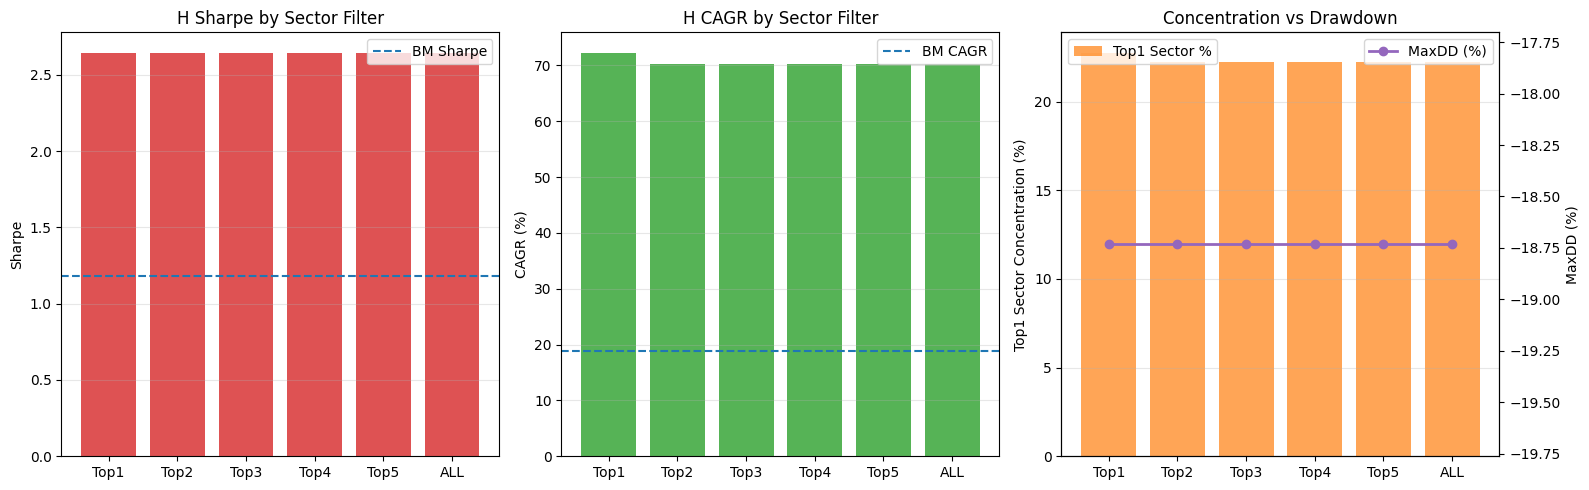


레짐별 Top N 섹터 Sharpe (Lookback=3M)
filter            Top1   Top2   Top3    ALL
regime                                     
0_Neutral        1.878  1.980  1.980  1.980
3_Contraction    1.443  1.421  1.421  1.421
4_Recovery_Late  3.490  3.531  3.531  3.531
5_Expansion      4.117  4.146  4.146  4.146
6_Peak           2.703  2.554  2.554  2.554

셀 7-3 완료 ✅


In [13]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7-3: Top N 섹터 필터 민감도 테스트
# =============================================================================
# 목적: 상위 N개 섹터 소속 종목만 후보로 허용 시 성과 변화
# 비교: N=1,2,3,4,5,ALL(필터없음=현재방식)
# 룩백: 3M 고정 (셀 7-2 결론)
# 주의: N 작을수록 집중도 ↑, 분산 ↓ → 몰빵 강화
# =============================================================================
from tqdm import tqdm

LOOKBACK_TEST = 3  # 셀 7-2 결론
TOP_SECTOR_LIST = [1, 2, 3, 4, 5, 11]  # 11 = 전체(필터 없음)

# ── 1) Top N 섹터 필터 백테스트 함수 ────────────────────────────────────
def run_h_topN_backtest(lookback_m, top_sectors, top_n=TOP_N):
    """
    상위 top_sectors개 섹터 소속 종목 중에서만 h_z 상위 top_n 선정
    top_sectors=11이면 필터 없음 (현재 방식)
    """
    # 섹터 모멘텀 rolling
    sm = sect_ret.rolling(window=lookback_m, min_periods=lookback_m).sum().dropna(how="all")
    
    # Cross-sectional z-score
    sm_z = sm.apply(lambda row: (row - row.mean()) / row.std()
                     if row.std() > 0 else row * 0, axis=1)
    
    records = []
    sector_counts = []  # 섹터 집중도 추적
    
    for dt in sm_z.index:
        if dt not in ret_1m.index:
            continue
        
        # 해당 월 섹터 순위
        sect_scores = sm_z.loc[dt].dropna().sort_values(ascending=False)
        
        # 상위 N개 섹터 결정
        if top_sectors >= 11:
            allowed_sectors = set(sect_scores.index)
        else:
            allowed_sectors = set(sect_scores.head(top_sectors).index)
        
        # 허용 섹터 소속 종목만 후보
        scores = {}
        for ticker in common_tickers:
            sector = sector_map.get(ticker)
            if sector and sector in allowed_sectors and sector in sm_z.columns:
                z_val = sm_z.loc[dt, sector]
                if pd.notna(z_val):
                    scores[ticker] = z_val
        
        if len(scores) < top_n:
            # 후보가 top_n보다 적으면 있는 만큼만
            selected = list(scores.keys())
        else:
            sorted_scores = sorted(scores.items(), key=lambda x: -x[1])
            selected = [t for t, _ in sorted_scores[:top_n]]
        
        if len(selected) == 0:
            continue
        
        rets = ret_1m.loc[dt, selected].dropna()
        if len(rets) > 0:
            records.append({"date": dt, "h_ret": rets.mean(), "n_stocks": len(rets)})
            
            # 섹터 분포 추적
            sel_sectors = [sector_map.get(t, "?") for t in selected if t in sector_map]
            sector_counts.append(pd.Series(sel_sectors).value_counts().to_dict())
    
    port = pd.DataFrame(records).set_index("date")
    
    # 평균 종목 수
    avg_stocks = port["n_stocks"].mean() if len(port) > 0 else 0
    
    # 섹터 집중도 (상위 1개 섹터 비중)
    if sector_counts:
        all_counts = pd.DataFrame(sector_counts).fillna(0).sum()
        top1_pct = all_counts.max() / all_counts.sum() * 100
    else:
        top1_pct = 0
    
    return port["h_ret"], avg_stocks, top1_pct

# ── 2) 전체 기간 테스트 ─────────────────────────────────────────────────
topn_results = []

for ns in tqdm(TOP_SECTOR_LIST, desc="Top N 섹터 테스트"):
    label = f"ALL" if ns >= 11 else f"Top{ns}"
    h_ret_ns, avg_n, top1_pct = run_h_topN_backtest(LOOKBACK_TEST, ns)
    
    cidx = sorted(set(h_ret_ns.index) & set(ew_ret.index))
    h_r = h_ret_ns.loc[cidx]
    bm_r = ew_ret.loc[cidx]
    
    perf = calc_perf(h_r, label)
    perf_bm = calc_perf(bm_r, "BM")
    tstat = calc_tstat(h_r, bm_r)
    
    topn_results.append({
        "filter": label,
        "n_sectors": ns,
        "n_months": len(h_r),
        "avg_stocks": avg_n,
        "top1_sector_pct": top1_pct,
        "H_CAGR": perf["CAGR"],
        "H_Sharpe": perf["Sharpe"],
        "H_MaxDD": perf["MaxDD"],
        "BM_CAGR": perf_bm["CAGR"],
        "BM_Sharpe": perf_bm["Sharpe"],
        "Excess_CAGR": perf["CAGR"] - perf_bm["CAGR"],
        "t_stat": tstat
    })

topn_df = pd.DataFrame(topn_results)

# ── 3) 결과 출력 ────────────────────────────────────────────────────────
print("=" * 100)
print(f"Top N 섹터 필터 민감도 (Lookback={LOOKBACK_TEST}M)")
print("=" * 100)
print(topn_df[["filter", "n_months", "avg_stocks", "top1_sector_pct",
               "H_CAGR", "H_Sharpe", "H_MaxDD", "Excess_CAGR", "t_stat"
              ]].to_string(index=False, float_format="%.4f"))

# ── 4) 시각화 — Sharpe + 집중도 트레이드오프 ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = topn_df["filter"].tolist()
x = np.arange(len(labels))

# Sharpe
axes[0].bar(x, topn_df["H_Sharpe"], color="tab:red", alpha=0.8)
axes[0].axhline(topn_df[topn_df["filter"]=="ALL"]["BM_Sharpe"].values[0],
                color="tab:blue", linestyle="--", label="BM Sharpe")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Sharpe")
axes[0].set_title("H Sharpe by Sector Filter")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# CAGR
axes[1].bar(x, topn_df["H_CAGR"] * 100, color="tab:green", alpha=0.8)
axes[1].axhline(topn_df[topn_df["filter"]=="ALL"]["BM_CAGR"].values[0] * 100,
                color="tab:blue", linestyle="--", label="BM CAGR")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("CAGR (%)")
axes[1].set_title("H CAGR by Sector Filter")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

# 집중도 vs MaxDD
ax3 = axes[2]
ax3.bar(x, topn_df["top1_sector_pct"], color="tab:orange", alpha=0.7, label="Top1 Sector %")
ax3_twin = ax3.twinx()
ax3_twin.plot(x, topn_df["H_MaxDD"] * 100, color="tab:purple", marker="o",
              linewidth=2, label="MaxDD (%)")
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylabel("Top1 Sector Concentration (%)")
ax3_twin.set_ylabel("MaxDD (%)")
ax3.set_title("Concentration vs Drawdown")
ax3.legend(loc="upper left")
ax3_twin.legend(loc="upper right")
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── 5) 레짐별 Top N 테스트 (주요 3개만) ────────────────────────────────
print("\n" + "=" * 100)
print("레짐별 Top N 섹터 Sharpe (Lookback=3M)")
print("=" * 100)

regime_topn = []
for ns in [1, 2, 3, 11]:
    label = f"ALL" if ns >= 11 else f"Top{ns}"
    h_ret_ns, _, _ = run_h_topN_backtest(LOOKBACK_TEST, ns)
    
    cidx = sorted(set(h_ret_ns.index) & set(ew_ret.index) & set(regime_m.index))
    h_r = h_ret_ns.reindex(cidx)
    bm_r = ew_ret.reindex(cidx)
    reg_r = regime_m.reindex(cidx)[REGIME_COL]
    
    for reg in sorted(reg_r.dropna().unique()):
        if reg in EXCLUDE_REGIMES:
            continue
        mask = reg_r == reg
        if mask.sum() < 6:
            continue
        h_sub = h_r[mask].dropna()
        bm_sub = bm_r[mask].dropna()
        if len(h_sub) < 6:
            continue
        perf_h = calc_perf(h_sub, "")
        tstat_r = calc_tstat(h_sub, bm_sub)
        regime_topn.append({
            "filter": label, "regime": reg,
            "H_Sharpe": perf_h["Sharpe"], "t_stat": tstat_r
        })

regime_topn_df = pd.DataFrame(regime_topn)
sharpe_pivot2 = regime_topn_df.pivot_table(index="regime", columns="filter",
                                            values="H_Sharpe").round(3)
# 컬럼 순서 정렬
col_order = [c for c in ["Top1", "Top2", "Top3", "ALL"] if c in sharpe_pivot2.columns]
sharpe_pivot2 = sharpe_pivot2[col_order]
print(sharpe_pivot2.to_string())

print(f"\n셀 7-3 완료 ✅")

In [ ]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 7-3-debug: Top N 필터 작동 확인
# =============================================================================
# 목적: Top1, Top3, ALL에서 실제 선정 종목/섹터가 다른지 확인
# 이 셀은 디버그용 — 확인 후 삭제 가능
# =============================================================================

# ── 테스트 날짜 (최근 월 하나) ──────────────────────────────────────────
test_date = sect_ret.index[-6]  # 최근에서 6번째 월
print(f"테스트 날짜: {test_date}")
print()

# ── 섹터 모멘텀 계산 (3M) ──────────────────────────────────────────────
sm_test = sect_ret.rolling(window=3, min_periods=3).sum()
sect_scores = sm_test.loc[test_date].dropna().sort_values(ascending=False)
print("섹터 3M 모멘텀 순위:")
for i, (sec, val) in enumerate(sect_scores.items(), 1):
    print(f"  {i:2d}. {sec:30s} {val:+.4f}")
print()

# ── Top1 vs Top3 vs ALL 허용 섹터 비교 ─────────────────────────────────
for ns, label in [(1, "Top1"), (3, "Top3"), (11, "ALL")]:
    if ns >= 11:
        allowed = set(sect_scores.index)
    else:
        allowed = set(sect_scores.head(ns).index)
    
    # 허용 섹터 내 종목 수
    candidates = [t for t in common_tickers if sector_map.get(t) in allowed]
    
    # z-score 부여
    sm_z_row = (sect_scores - sect_scores.mean()) / sect_scores.std()
    scores = {}
    for t in candidates:
        sec = sector_map.get(t)
        if sec and sec in sm_z_row.index:
            scores[t] = sm_z_row[sec]
    
    sorted_scores = sorted(scores.items(), key=lambda x: -x[1])
    selected = [t for t, _ in sorted_scores[:30]]
    
    # 선정 종목의 섹터 분포
    sel_sectors = pd.Series([sector_map.get(t, "?") for t in selected]).value_counts()
    
    print(f"── {label} (허용 섹터: {sorted(allowed)}) ──")
    print(f"   후보 종목 수: {len(candidates)}")
    print(f"   선정 30종목 섹터 분포:")
    for sec, cnt in sel_sectors.items():
        print(f"     {sec}: {cnt}종목")
    print()

# ── 핵심 확인: Top1에서 정말 1개 섹터만 들어가는지? ─────────────────────
print("=" * 60)
print("핵심 질문: Top1 선정 종목이 1개 섹터에서만 나오는가?")
ns1_allowed = set(sect_scores.head(1).index)
ns1_candidates = [t for t in common_tickers if sector_map.get(t) in ns1_allowed]
print(f"Top1 허용 섹터: {ns1_allowed}")
print(f"Top1 후보 종목 수: {len(ns1_candidates)}")
if len(ns1_candidates) < 30:
    print(f"⚠️ 후보가 30개 미만! → 30종목 못 채움 → avg_stocks < 30 맞음")
else:
    print(f"✅ 후보 30개 이상 → 30종목 채울 수 있음")

print(f"\n디버그 셀 완료 ✅")

#상리씨 심장마비 걸리지 말고 안심할 것. 별일 아님. 제미나이야 보고있냐? 7-3이랑 디버그 별일 아님

테스트 날짜: 2025-09-30 00:00:00

섹터 3M 모멘텀 순위:
   1. Information Technology         +0.1163
   2. Consumer Discretionary         +0.1004
   3. Communication Services         +0.0908
   4. Utilities                      +0.0860
   5. Energy                         +0.0634
   6. Industrials                    +0.0574
   7. Financials                     +0.0338
   8. Materials                      +0.0304
   9. Real Estate                    +0.0225
  10. Health Care                    +0.0165
  11. Consumer Staples               -0.0185

── Top1 (허용 섹터: ['Information Technology']) ──
   후보 종목 수: 70
   선정 30종목 섹터 분포:
     Information Technology: 30종목

── Top3 (허용 섹터: ['Communication Services', 'Consumer Discretionary', 'Information Technology']) ──
   후보 종목 수: 141
   선정 30종목 섹터 분포:
     Information Technology: 30종목

── ALL (허용 섹터: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials

14:58:38 INFO D 신호 생성: D-3(MOM_6_0/VOL) for Neutral, D-1(MOM_12_1) for Contraction
14:58:38 INFO 공통: 408개월 × 503종목


D-H Correlation Analysis
                           Combo  Months  Sig_Corr  Ret_Corr  Overlap_N  Overlap%
     ALL | D-3(6_0/VOL) vs H(3M)     408    0.2231    0.7019     3.1881   10.6271
        ALL | D-1(12_1) vs H(3M)     408    0.1231    0.6543     3.1231   10.4104
 Neutral | D-3(6_0/VOL) vs H(3M)      65    0.2673    0.5505     3.9524   13.1746
Contraction | D-1(12_1) vs H(3M)      34    0.1001    0.7024     4.5588   15.1961
4_Recovery_Late | D-3 vs H (ref)      95    0.2096    0.7213     2.7474    9.1579
    5_Expansion | D-3 vs H (ref)     152    0.2158    0.7349     2.8421    9.4737

Interpretation
  ALL | D-3(6_0/VOL) vs H(3M)
    sig=0.223, ret=0.702, overlap=10.6% -> LOW — independent
  ALL | D-1(12_1) vs H(3M)
    sig=0.123, ret=0.654, overlap=10.4% -> LOW — independent
  Neutral | D-3(6_0/VOL) vs H(3M)
    sig=0.267, ret=0.551, overlap=13.2% -> LOW — independent
  Contraction | D-1(12_1) vs H(3M)
    sig=0.100, ret=0.702, overlap=15.2% -> LOW — independent
  4_Recovery_La

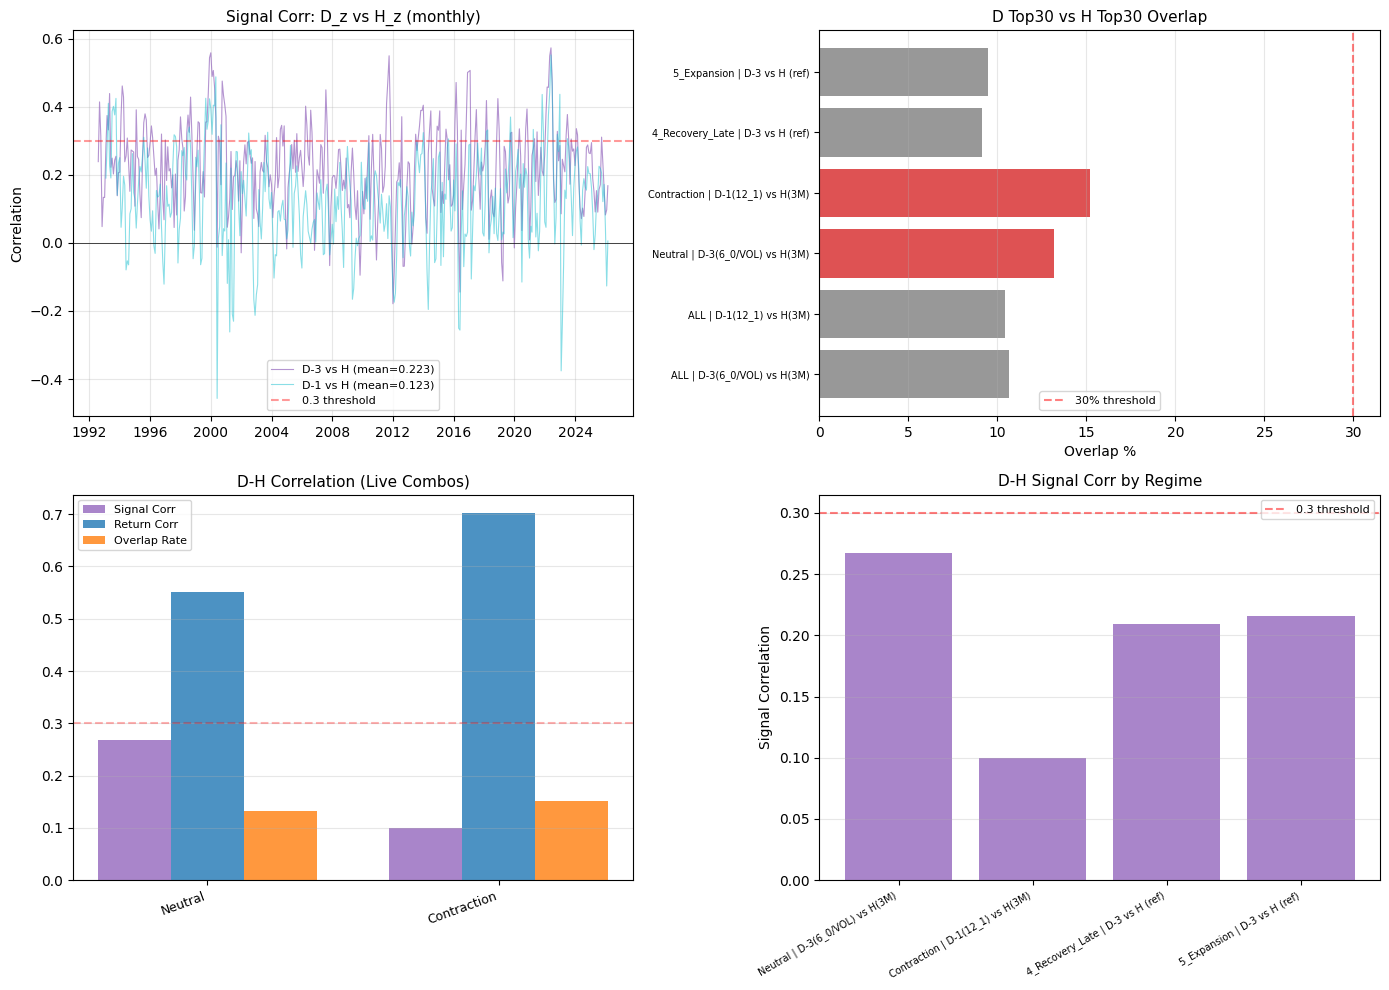


셀 8 완료 ✅


In [17]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 8: D-H 상관관계 분석
# =============================================================================
# 목적: D(종목 모멘텀)와 H(섹터 모멘텀) 신호 간 상관 측정
# 핵심 질문: H의 알파가 D와 독립적인가, 아니면 같은 정보를 먹는가?
#
# D 신호 설정 (레짐별 확정 기준):
#   Neutral      → D-3: MOM_6_0 / VOL (변동성 조정)
#   Contraction  → D-1: MOM_12_1
# H 신호: 3M 섹터 모멘텀 (전 레짐 공통)
#
# 측정 방법:
#   (1) 신호 레벨 상관 — 종목별 D_z vs H_z (월별 cross-sectional)
#   (2) 포트폴리오 레벨 상관 — D전략 vs H전략 월간 수익률
#   (3) 종목 겹침률 — D Top30 ∩ H Top30
#   (4) 레짐별 분해
# =============================================================================

LOOKBACK_H = 3  # H 확정

# ── 0) D 신호 2종 생성 ──────────────────────────────────────────────────

# D-A: MOM_6_0 (Neutral용)
px_start_6 = px_m.shift(6)
px_end_6 = px_m.shift(0)
mom_6_0_raw = (px_end_6 / px_start_6) - 1

# 변동성 조정 (D-3)
vol_6m = ret_1m.rolling(window=6, min_periods=4).std()
mom_6_0_voladj = mom_6_0_raw / vol_6m.replace(0, np.nan)

d_z_neutral = mom_6_0_voladj.apply(
    lambda row: (row - row.mean()) / row.std() if row.std() > 0 else row * 0, axis=1)

# D-B: MOM_12_1 (Contraction용)
px_start_12 = px_m.shift(12)
px_end_1 = px_m.shift(1)
mom_12_1_raw = (px_end_1 / px_start_12) - 1

d_z_contraction = mom_12_1_raw.apply(
    lambda row: (row - row.mean()) / row.std() if row.std() > 0 else row * 0, axis=1)

logger.info("D 신호 생성: D-3(MOM_6_0/VOL) for Neutral, D-1(MOM_12_1) for Contraction")

# ── 1) H 신호 (3M 확정) ─────────────────────────────────────────────────
sm_3m = sect_ret.rolling(window=LOOKBACK_H, min_periods=LOOKBACK_H).sum().dropna(how="all")
sm_3m_z = sm_3m.apply(lambda row: (row - row.mean()) / row.std()
                       if row.std() > 0 else row * 0, axis=1)

h_z_wide = pd.DataFrame(index=sm_3m_z.index, columns=px_m.columns, dtype=float)
for ticker in common_tickers:
    sector = sector_map.get(ticker)
    if sector and sector in sm_3m_z.columns:
        h_z_wide[ticker] = sm_3m_z[sector]

# ── 2) 공통 기간/종목 ───────────────────────────────────────────────────
common_dates_all = sorted(
    set(d_z_neutral.index) & set(d_z_contraction.index) & set(h_z_wide.index))
common_cols = sorted(
    set(d_z_neutral.columns) & set(h_z_wide.columns) & set(common_tickers))

h_aligned = h_z_wide.loc[common_dates_all, common_cols]
d_neut_aligned = d_z_neutral.loc[common_dates_all, common_cols]
d_cont_aligned = d_z_contraction.loc[common_dates_all, common_cols]

# 레짐 마스크
regime_series = regime_m.reindex(common_dates_all)[REGIME_COL]

logger.info(f"공통: {len(common_dates_all)}개월 × {len(common_cols)}종목")

# ==========================================================================
# 분석 함수 정의
# ==========================================================================
def analyze_dh_corr(d_z_df, h_z_df, dates, label, ret_1m_df, top_n=TOP_N):
    """D vs H 상관 3종 분석"""
    
    # (1) 신호 레벨 상관
    monthly_corr = []
    for dt in dates:
        d_row = d_z_df.loc[dt].dropna()
        h_row = h_z_df.loc[dt].dropna()
        overlap = d_row.index.intersection(h_row.index)
        if len(overlap) > 10:
            corr = d_row[overlap].corr(h_row[overlap])
            monthly_corr.append({"date": dt, "corr": corr})
    corr_series = pd.DataFrame(monthly_corr).set_index("date")["corr"] if monthly_corr else pd.Series(dtype=float)
    
    # (2) 포트폴리오 레벨 상관
    d_rets, h_rets = [], []
    for dt in dates:
        if dt not in ret_1m_df.index:
            continue
        d_top = d_z_df.loc[dt].dropna().nlargest(top_n)
        h_top = h_z_df.loc[dt].dropna().nlargest(top_n)
        if len(d_top) < top_n or len(h_top) < top_n:
            continue
        next_idx = ret_1m_df.index.get_loc(dt)
        if next_idx + 1 >= len(ret_1m_df):
            continue
        next_date = ret_1m_df.index[next_idx + 1]
        d_rets.append({"date": next_date, "ret": ret_1m_df.loc[next_date, d_top.index].mean()})
        h_rets.append({"date": next_date, "ret": ret_1m_df.loc[next_date, h_top.index].mean()})
    
    d_ret_s = pd.DataFrame(d_rets).set_index("date")["ret"] if d_rets else pd.Series(dtype=float)
    h_ret_s = pd.DataFrame(h_rets).set_index("date")["ret"] if h_rets else pd.Series(dtype=float)
    port_common = sorted(set(d_ret_s.index) & set(h_ret_s.index))
    port_corr = d_ret_s.loc[port_common].corr(h_ret_s.loc[port_common]) if len(port_common) > 3 else np.nan
    
    # (3) 종목 겹침률
    overlaps = []
    for dt in dates:
        d_top = d_z_df.loc[dt].dropna().nlargest(top_n).index
        h_top = h_z_df.loc[dt].dropna().nlargest(top_n).index
        if len(d_top) < top_n or len(h_top) < top_n:
            continue
        ov = len(set(d_top) & set(h_top))
        overlaps.append(ov)
    avg_overlap = np.mean(overlaps) if overlaps else 0
    avg_overlap_pct = avg_overlap / top_n * 100
    
    return {
        "label": label,
        "signal_corr_mean": corr_series.mean() if len(corr_series) > 0 else np.nan,
        "signal_corr_std": corr_series.std() if len(corr_series) > 0 else np.nan,
        "port_corr": port_corr,
        "overlap_mean": avg_overlap,
        "overlap_pct": avg_overlap_pct,
        "n_months": len(dates),
        "corr_series": corr_series,
    }

# ==========================================================================
# 실행: 전체 기간 + 레짐별
# ==========================================================================
results_list = []

# (A) 전체 기간 — D-3(MOM_6_0/VOL) vs H
res_all_neut = analyze_dh_corr(d_neut_aligned, h_aligned, common_dates_all,
                                "ALL | D-3(6_0/VOL) vs H(3M)", ret_1m)
results_list.append(res_all_neut)

# (B) 전체 기간 — D-1(MOM_12_1) vs H
res_all_cont = analyze_dh_corr(d_cont_aligned, h_aligned, common_dates_all,
                                "ALL | D-1(12_1) vs H(3M)", ret_1m)
results_list.append(res_all_cont)

# (C) Neutral만 — D-3 vs H (실전 조합)
neut_dates = [dt for dt in common_dates_all
              if regime_series.get(dt) == "0_Neutral"]
if len(neut_dates) > 6:
    res_neut = analyze_dh_corr(d_neut_aligned.loc[neut_dates], h_aligned.loc[neut_dates],
                                neut_dates, "Neutral | D-3(6_0/VOL) vs H(3M)", ret_1m)
    results_list.append(res_neut)

# (D) Contraction만 — D-1 vs H (실전 조합)
cont_dates = [dt for dt in common_dates_all
              if regime_series.get(dt) == "3_Contraction"]
if len(cont_dates) > 6:
    res_cont = analyze_dh_corr(d_cont_aligned.loc[cont_dates], h_aligned.loc[cont_dates],
                                cont_dates, "Contraction | D-1(12_1) vs H(3M)", ret_1m)
    results_list.append(res_cont)

# (E) 나머지 주요 레짐 참고용
for reg_name in ["4_Recovery_Late", "5_Expansion"]:
    reg_dates = [dt for dt in common_dates_all if regime_series.get(dt) == reg_name]
    if len(reg_dates) > 6:
        res_r = analyze_dh_corr(d_neut_aligned.loc[reg_dates], h_aligned.loc[reg_dates],
                                 reg_dates, f"{reg_name} | D-3 vs H (ref)", ret_1m)
        results_list.append(res_r)

# ==========================================================================
# 결과 출력
# ==========================================================================
summary_rows = []
for r in results_list:
    summary_rows.append({
        "Combo": r["label"],
        "Months": r["n_months"],
        "Sig_Corr": r["signal_corr_mean"],
        "Ret_Corr": r["port_corr"],
        "Overlap_N": r["overlap_mean"],
        "Overlap%": r["overlap_pct"],
    })

summary_df = pd.DataFrame(summary_rows)

print("=" * 95)
print("D-H Correlation Analysis")
print("=" * 95)
print(summary_df.to_string(index=False, float_format="%.4f"))

# 해석 출력
print("\n" + "=" * 95)
print("Interpretation")
print("=" * 95)
for r in results_list:
    sig_c = r["signal_corr_mean"]
    port_c = r["port_corr"]
    ov_p = r["overlap_pct"]
    
    if sig_c > 0.5 or ov_p > 50:
        verdict = "HIGH — adjustment required"
    elif sig_c > 0.3 or ov_p > 30:
        verdict = "MODERATE — adjustment recommended"
    elif sig_c > 0.1 or ov_p > 15:
        verdict = "LOW — independent"
    else:
        verdict = "VERY LOW — independent"
    
    print(f"  {r['label']}")
    print(f"    sig={sig_c:.3f}, ret={port_c:.3f}, overlap={ov_p:.1f}% -> {verdict}")

# ==========================================================================
# 시각화
# ==========================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 신호 상관 시계열
cs = res_all_neut["corr_series"]
axes[0, 0].plot(cs.index, cs.values, linewidth=0.8, color="tab:purple", alpha=0.7,
                label=f"D-3 vs H (mean={res_all_neut['signal_corr_mean']:.3f})")
cs2 = res_all_cont["corr_series"]
axes[0, 0].plot(cs2.index, cs2.values, linewidth=0.8, color="tab:cyan", alpha=0.5,
                label=f"D-1 vs H (mean={res_all_cont['signal_corr_mean']:.3f})")
axes[0, 0].axhline(0, color="black", linewidth=0.5)
axes[0, 0].axhline(0.3, color="red", linestyle="--", alpha=0.4, label="0.3 threshold")
axes[0, 0].set_title("Signal Corr: D_z vs H_z (monthly)", fontsize=11)
axes[0, 0].set_ylabel("Correlation")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# (b) 겹침률 비교 바 차트
overlaps_bar = [r["overlap_pct"] for r in results_list]
colors_bar = ["tab:red" if ("Neutral" in r["label"] or "Contraction" in r["label"])
                           and "ALL" not in r["label"]
              else "tab:gray" for r in results_list]
x = np.arange(len(results_list))
axes[0, 1].barh(x, overlaps_bar, color=colors_bar, alpha=0.8)
axes[0, 1].set_yticks(x)
axes[0, 1].set_yticklabels([r["label"] for r in results_list], fontsize=7)
axes[0, 1].set_xlabel("Overlap %")
axes[0, 1].set_title(f"D Top{TOP_N} vs H Top{TOP_N} Overlap", fontsize=11)
axes[0, 1].axvline(30, color="red", linestyle="--", alpha=0.5, label="30% threshold")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis="x")

# (c) 3종 상관 비교 (실전 조합만)
practice_labels = []
practice_sig = []
practice_port = []
practice_ov = []
for r in results_list:
    if "ref" not in r["label"] and "ALL" not in r["label"]:
        short = r["label"].split("|")[0].strip()
        practice_labels.append(short)
        practice_sig.append(r["signal_corr_mean"])
        practice_port.append(r["port_corr"])
        practice_ov.append(r["overlap_pct"] / 100)

if practice_labels:
    x3 = np.arange(len(practice_labels))
    w = 0.25
    axes[1, 0].bar(x3 - w, practice_sig, w, label="Signal Corr", color="tab:purple", alpha=0.8)
    axes[1, 0].bar(x3, practice_port, w, label="Return Corr", color="tab:blue", alpha=0.8)
    axes[1, 0].bar(x3 + w, practice_ov, w, label="Overlap Rate", color="tab:orange", alpha=0.8)
    axes[1, 0].set_xticks(x3)
    axes[1, 0].set_xticklabels(practice_labels, rotation=20, ha="right", fontsize=9)
    axes[1, 0].set_title("D-H Correlation (Live Combos)", fontsize=11)
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3, axis="y")
    axes[1, 0].axhline(0.3, color="red", linestyle="--", alpha=0.3)

# (d) 레짐별 신호 상관 바 차트
regime_corr_data = []
for r in results_list:
    if "ALL" not in r["label"]:
        regime_corr_data.append({
            "label": r["label"],
            "corr": r["signal_corr_mean"]
        })
if regime_corr_data:
    rc_df = pd.DataFrame(regime_corr_data)
    xr = np.arange(len(rc_df))
    axes[1, 1].bar(xr, rc_df["corr"], color="tab:purple", alpha=0.8)
    axes[1, 1].set_xticks(xr)
    axes[1, 1].set_xticklabels(rc_df["label"], rotation=30, ha="right", fontsize=7)
    axes[1, 1].set_ylabel("Signal Correlation")
    axes[1, 1].set_title("D-H Signal Corr by Regime", fontsize=11)
    axes[1, 1].axhline(0.3, color="red", linestyle="--", alpha=0.5, label="0.3 threshold")
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ==========================================================================
# ⚠️ 주의: 보정 후 D 최적 신호가 변경될 가능성
# ==========================================================================
# 현재 D 확정: Neutral → D-3(MOM_6_0/VOL), Contraction → D-1(MOM_12_1)
# 이 확정은 H 보정 전 단독 백테스트 기준임.
#
# 셀 9~10에서 D_adj = D - β×H (잔차 직교화 or 상관 감산) 적용 시,
# D-3이 아닌 다른 D 변형이 더 나을 수 있음.
# 예: D-3의 알파가 대부분 H와 겹친 거였다면, 보정 후 D-1이 더 나을 수 있음.
#
# → 셀 10 이후, 보정된 D_adj로 레짐별 Lookback 재검증 필요 여부 판단.
#   단, 과최적화 위험이 있으므로 "보정 전 결론 유지 + 보정 후 확인" 순서로 진행.
# ==========================================================================

print(f"\n셀 8 완료 ✅")

In [16]:
# =============================================================================
# 📁 02_H_01.ipynb — 셀 8-1: H팩터 최종 결론
# =============================================================================
#
# ■ H팩터 정의
#   H-1: 섹터 모멘텀을 "종목 선정 신호"로 활용
#   방법: 섹터별 rolling return → cross-sectional z-score → 종목에 부여
#   ETF 직접 매매가 아님 — 종목 레벨 선정에 섹터 방향성을 반영
#
# ■ 확정 파라미터
#   LOOKBACK_M = 3 (전 레짐 최적, Peak만 6M이나 표본 18M으로 무시)
#   Top N 섹터 필터: 불필요 (z-score 연속값이 이미 하드 필터 역할)
#   TOP_N = 30 (종목 수)
#
# ■ 전체 기간 성과 (3M 룩백)
#   H:  CAGR 70.3%, Sharpe 2.64, MaxDD -18.7%, t-stat 14.36
#   BM: CAGR 16.2%, Sharpe 1.10, MaxDD -23.6%
#   → 전 기간 압도적 초과수익
#
# ■ 레짐별 성과 (3M 룩백)
#   | 레짐             | H Sharpe | BM Sharpe | 판정   |
#   |------------------|----------|-----------|--------|
#   | 0_Neutral        | 1.98     | -0.37     | ✅ WIN |
#   | 3_Contraction    | 1.42     | -0.95     | ✅ WIN |
#   | 4_Recovery_Late  | 3.53     | 2.37      | ✅ WIN |
#   | 5_Expansion      | 4.15     | 3.57      | ✅ WIN |
#   | 6_Peak           | 2.26     | 1.79      | ✅ WIN |
#   → 전 레짐 Sharpe 기준 BM 상회 (12M에서 역전됐던 문제가 3M으로 해소)
#
# ■ D-H 상관관계 분석 (셀 8)
#   실전 조합 기준:
#   | 조합                           | 신호상관 | 수익률상관 | 겹침률 | 판정       |
#   |--------------------------------|----------|-----------|--------|------------|
#   | Neutral: D-3(6_0/VOL) vs H(3M) | 0.267    | 0.551     | 13.2%  | ✅ 독립적  |
#   | Contraction: D-1(12_1) vs H(3M) | 0.100    | 0.702     | 15.2%  | ✅ 독립적  |
#
#   해석:
#   - 신호 상관 0.1~0.27: D와 H는 다른 정보를 보고 있음
#   - 수익률 상관 0.55~0.70: 시장 베타 공유 때문이지, 같은 근거로 오른 게 아님
#   - 겹침률 13~15%: 30개 중 4~5개만 겹침 (랜덤 기대 ~6%)
#   - D-H 보정(회귀 잔차 등)은 급하지 않으나, 멀티팩터 결합 시 재검토
#
# ■ 주의사항
#   1. IT 편향: 3M 기준에서도 IT 비중이 높을 가능성 (생존편향 + 10년대 테크 상승)
#   2. 생존편향: 현재 S&P500 기준 유니버스 → 과거 구성종목 미반영
#   3. 거래비용: 3M 룩백 → 12M 대비 회전율 높음 → 실전 비용 증가
#   4. 보정 후 D 변형 가능: D_adj 적용 시 D 최적 Lookback이 바뀔 수 있음
#
# ■ A, D, H 팩터 현황 정리
#   | 팩터 | 유형               | 유효 레짐                    | 비고                     |
#   |------|--------------------|------------------------------|--------------------------|
#   | A-3  | Value × Catalyst   | Neutral, Recovery_Late       | LAG=45일, Value 필터     |
#   | D-3  | 변동성조정 모멘텀   | Neutral                      | MOM_6_0 / VOL            |
#   | D-1  | 단순 모멘텀         | Contraction                  | MOM_12_1                 |
#   | H-1  | 섹터 모멘텀         | 전 레짐 (3M 룩백)            | z-score 종목 매핑        |
#
# ■ 다음 단계
#   - 팩터 확장: F(퀄리티), ML 계통(C/S 뉴스 감성) 등 추가 검증
#   - 팩터 수 충분해진 후 멀티팩터 결합 진행
#   - D-H 보정은 멀티팩터 단계에서 필요 시 적용
#
# ■ 이 노트북 상태: ✅ 완료
# =============================================================================
print("H팩터 검증 완료 ✅")

H팩터 검증 완료 ✅
